## Setup and Model  framework

This cell prepares the computational environment for the empirical pipeline. The project combines classical machine learning, Bayesian statistical learning, hidden-state modelling and sequential decision-making. The main empirical object is a daily Indian equity-market panel containing market returns, sector returns, institutional flows, volatility indicators and derived game-theoretic variables.

Mathematically, the project studies a prediction problem of the form

$$
y_{s,t+h} = f(X_{s,t}, G_t, Z_t) + \epsilon_{s,t},
$$

where \(s\) indexes sectors, \(t\) indexes trading days, \(h\) is the forecasting horizon, \(X_{s,t}\) contains market and sector-level covariates, \(G_t\) contains FII--DII strategic interaction variables, and \(Z_t\) represents latent market-regime information.

For downside classification, the target is written as

$$
y_{s,t+h} \sim \mathrm{Bernoulli}(p_{s,t}),
$$

with

$$
p_{s,t} = P(y_{s,t+h}=1 \mid X_{s,t}, G_t, Z_t).
$$

The baseline models estimate this probability using standard discriminative classifiers such as logistic regression, random forests, gradient boosting, Gaussian process classification and XGBoost. These provide non-Bayesian benchmarks for predictive performance.

The Bayesian models extend the same prediction task by placing prior distributions on unknown parameters and estimating posterior uncertainty. For example, a Bayesian logistic model can be written as

$$
\mathrm{logit}(p_{s,t}) = \alpha_s + X_{s,t}^{\top}\beta,
$$

with priors such as

$$
\beta_j \sim N(0,\tau^2).
$$

The PyMC model generalises this into a hierarchical structure, where sector-specific intercepts are partially pooled:

$$
\alpha_s \sim N(\mu_\alpha,\sigma_\alpha^2).
$$

This allows each sector to have its own baseline downside risk while still sharing statistical strength across the full market panel.

The hidden-regime layer uses a Gaussian Hidden Markov Model. The latent market state \(z_t\) evolves according to

$$
P(z_t \mid z_{t-1}),
$$

while observed market features are generated conditionally on the current regime:

$$
X_t \mid z_t=k \sim N(\mu_k,\Sigma_k).
$$

The model therefore estimates filtered regime probabilities,

$$
P(z_t=k \mid X_{1:t}),
$$

which are used as regime-aware inputs rather than relying on fixed market labels.

Finally, the Bayesian bandit layer treats allocation as a sequential decision problem. At each rebalance date, the model observes a context vector \(c_t\), selects an action \(a_t\), receives a realised reward \(r_t\), and updates beliefs about future rewards. This converts the probabilistic forecasting model into a simple decision rule under uncertainty.

Overall, the setup imports the packages needed for four connected tasks: data extraction, exploratory analysis, probabilistic forecasting, and strategy evaluation.

In [ ]:
import sys
import subprocess
import importlib


def ensure(pkg, module = None):
    try:
        importlib.import_module(module or pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


for pkg, module in [
    ("yfinance", "yfinance"),
    ("xgboost", "xgboost"),
    ("hmmlearn", "hmmlearn"),
    ("pymc", "pymc"),
    ("arviz", "arviz"),
    ("seaborn", "seaborn"),
]:
    ensure(pkg, module)


import os
import time
import warnings
import requests
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pymc as pm
import arviz as az

from scipy.special import expit, logsumexp

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, BayesianRidge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score,
    log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier,
)
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, DotProduct
from xgboost import XGBClassifier
from hmmlearn.hmm import GaussianHMM
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

In [ ]:
@dataclass
class Config:
    start_date: str = "2015-01-01"
    end_date: str = "2026-05-01"
    data_dir: str = "/content/st451_fii_dii_data"
    horizon: int = 5
    test_size: float = 0.25
    downside_quantile: float = 0.20
    action_z: float = 0.60
    random_state: int = 42
    allow_demo_if_fiidii_missing: bool = True
    min_fiidii_dates: int = 250
    pymc_max_rows: int = 6000
    pymc_draws: int = 1000
    pymc_tune: int = 1500
    pymc_chains: int = 4
    transaction_cost: float = 0.0005
    rebalance_step: int = 5
    nse_index_names: dict = field(default_factory = lambda: {
        "NIFTY50": "NIFTY 50",
        "BANK": "NIFTY BANK",
        "IT": "NIFTY IT",
        "FMCG": "NIFTY FMCG",
        "AUTO": "NIFTY AUTO",
        "PHARMA": "NIFTY PHARMA",
        "METAL": "NIFTY METAL",
        "REALTY": "NIFTY REALTY",
        "FIN_SERVICE": "NIFTY FINANCIAL SERVICES",
    })
    yahoo_fallback: dict = field(default_factory = lambda: {
        "NIFTY50": "^NSEI",
        "VIX": "^INDIAVIX",
        "BANK": "^NSEBANK",
        "IT": "^CNXIT",
        "FMCG": "^CNXFMCG",
        "AUTO": "^CNXAUTO",
        "PHARMA": "^CNXPHARMA",
        "METAL": "^CNXMETAL",
        "REALTY": "^CNXREALTY",
        "FIN_SERVICE": "NIFTY_FIN_SERVICE.NS",
    })
    defensive_sectors: tuple = ("FMCG", "PHARMA", "IT")
    cyclical_sectors: tuple = ("BANK", "AUTO", "METAL", "REALTY", "FIN_SERVICE")


cfg = Config()
Path(cfg.data_dir).mkdir(parents = True, exist_ok = True)
cfg

Config(start_date='2015-01-01', end_date='2026-05-01', data_dir='/content/st451_fii_dii_data', horizon=5, test_size=0.25, downside_quantile=0.2, action_z=0.6, random_state=42, allow_demo_if_fiidii_missing=True, min_fiidii_dates=250, pymc_max_rows=6000, pymc_draws=1000, pymc_tune=1500, pymc_chains=4, transaction_cost=0.0005, rebalance_step=5, nse_index_names={'NIFTY50': 'NIFTY 50', 'BANK': 'NIFTY BANK', 'IT': 'NIFTY IT', 'FMCG': 'NIFTY FMCG', 'AUTO': 'NIFTY AUTO', 'PHARMA': 'NIFTY PHARMA', 'METAL': 'NIFTY METAL', 'REALTY': 'NIFTY REALTY', 'FIN_SERVICE': 'NIFTY FINANCIAL SERVICES'}, yahoo_fallback={'NIFTY50': '^NSEI', 'VIX': '^INDIAVIX', 'BANK': '^NSEBANK', 'IT': '^CNXIT', 'FMCG': '^CNXFMCG', 'AUTO': '^CNXAUTO', 'PHARMA': '^CNXPHARMA', 'METAL': '^CNXMETAL', 'REALTY': '^CNXREALTY', 'FIN_SERVICE': 'NIFTY_FIN_SERVICE.NS'}, defensive_sectors=('FMCG', 'PHARMA', 'IT'), cyclical_sectors=('BANK', 'AUTO', 'METAL', 'REALTY', 'FIN_SERVICE'))

## Functions to be used in the Models

In [ ]:
def find_col(self, df, pats):
        low = {c: str(c).lower().replace(" ", "_") for c in df.columns}
        for p in pats:
            for c, l in low.items():
                if p.lower() in l:
                    return c
        return None

In [ ]:
class NSEDataClient:
    def __init__(self, cfg):
        self.cfg = cfg
        self.base = "https://www.nseindia.com"
        self.session = requests.Session()
        self.session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/121.0 Safari/537.36",
            "Accept": "application/json,text/plain,*/*",
            "Accept-Language": "en-US,en;q=0.9",
            "Referer": "https://www.nseindia.com/",
        })
        self.refresh()

    def refresh(self):
        try:
            self.session.get(self.base, timeout = 20)
        except Exception:
            pass

    def dmy(self, x):
        return pd.to_datetime(x).strftime("%d-%m-%Y")

    def chunks(self, start, end, days = 360):
        cur = pd.to_datetime(start)
        end = pd.to_datetime(end)
        while cur <= end:
            nxt = min(cur + pd.Timedelta(days = days), end)
            yield cur, nxt
            cur = nxt + pd.Timedelta(days = 1)

    def get_json(self, endpoint, params = None):
        url = self.base + endpoint
        r = self.session.get(url, params = params, timeout = 30)
        if r.status_code in (401, 403):
            self.refresh()
            r = self.session.get(url, params = params, timeout = 30)
        r.raise_for_status()
        return r.json()

    def largest_table(self, obj):
        tables = []
        def walk(x):
            if isinstance(x, list):
                if len(x) and all(isinstance(i, dict) for i in x):
                    tables.append(pd.json_normalize(x))
                for i in x:
                    walk(i)
            if isinstance(x, dict):
                for v in x.values():
                    walk(v)
        walk(obj)
        return max(tables, key = len).copy() if tables else pd.DataFrame()

    def num(self, s):
        return pd.to_numeric(
            pd.Series(s).astype(str).str.replace(",", "", regex = False).str.replace("%", "", regex = False),
            errors = "coerce",
        )



    def yahoo_series(self, ticker, label):
        df = yf.download(ticker, start = self.cfg.start_date, end = self.cfg.end_date, progress = False, auto_adjust = False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.reset_index().rename(columns = {"Date": "date", "Close": label})
        df["date"] = pd.to_datetime(df["date"])
        return df[["date", label]].dropna()

    def index_history(self, index_name, label):
        path = Path(self.cfg.data_dir) / f"index_{label}.csv"
        if path.exists():
            return pd.read_csv(path)
        frames = []
        for a, b in self.chunks(self.cfg.start_date, self.cfg.end_date):
            try:
                js = self.get_json("/api/historical/indicesHistory", {"indexType": index_name, "from": self.dmy(a), "to": self.dmy(b)})
                df = self.largest_table(js)
                if len(df):
                    frames.append(df)
                time.sleep(0.25)
            except Exception:
                time.sleep(0.25)
        if frames:
            out = pd.concat(frames, ignore_index = True).drop_duplicates()
            out.to_csv(path, index = False)
            return out
        ticker = self.cfg.yahoo_fallback.get(label)
        if ticker is None:
            raise RuntimeError(label)
        out = self.yahoo_series(ticker, label)
        out.to_csv(path, index = False)
        return out

    def vix_history(self):
        path = Path(self.cfg.data_dir) / "india_vix.csv"
        if path.exists():
            return pd.read_csv(path)
        frames = []
        for a, b in self.chunks(self.cfg.start_date, self.cfg.end_date):
            try:
                js = self.get_json("/api/historical/vixhistory", {"from": self.dmy(a), "to": self.dmy(b)})
                df = self.largest_table(js)
                if len(df):
                    frames.append(df)
                time.sleep(0.25)
            except Exception:
                time.sleep(0.25)
        if frames:
            out = pd.concat(frames, ignore_index = True).drop_duplicates()
            out.to_csv(path, index = False)
            return out
        out = self.yahoo_series(self.cfg.yahoo_fallback["VIX"], "vix_close")
        out.to_csv(path, index = False)
        return out

    def fiidii_latest(self):
        try:
            js = self.get_json("/api/fiidiiTradeReact")
            return self.largest_table(js)
        except Exception:
            return pd.DataFrame()


class DataManager:
    def __init__(self, cfg):
        self.cfg = cfg
        self.data_dir = Path(cfg.data_dir)
        self.client = NSEDataClient(cfg)

    def num(self, s):
        return pd.to_numeric(
            pd.Series(s).astype(str).str.replace(",", "", regex = False).str.replace("+", "", regex = False),
            errors = "coerce",
        )



    def read_csv(self, name):
        path = self.data_dir / name
        return pd.read_csv(path) if path.exists() else None

    def clean_vix(self, raw):
        date_col = self.find_col(raw, ["date", "timestamp"])
        close_col = self.find_col(raw, ["vix_close", "close", "closing"])
        out = pd.DataFrame({
            "date": pd.to_datetime(raw[date_col], errors = "coerce", dayfirst = True),
            "vix_close": self.num(raw[close_col]),
        })
        return out.dropna().drop_duplicates("date").sort_values("date")

    def clean_index_raw(self, raw, label):
        date_col = self.find_col(raw, ["date", "timestamp"])
        close_col = self.find_col(raw, [label.lower(), "close_index_val", "closing", "close", "last"])
        out = pd.DataFrame({
            "date": pd.to_datetime(raw[date_col], errors = "coerce", dayfirst = True),
            label: self.num(raw[close_col]),
        })
        return out.dropna().drop_duplicates("date").sort_values("date")

    def load_prices(self):
        local = self.read_csv("prices.csv")
        if local is not None:
            local["date"] = pd.to_datetime(local["date"], errors = "coerce", dayfirst = True)
            return local.dropna(subset = ["date"]).sort_values("date"), "local_prices_csv"
        tables = []
        failures = []
        for label, index_name in self.cfg.nse_index_names.items():
            try:
                raw = self.client.index_history(index_name, label)
                clean = self.clean_index_raw(raw, label)
                if len(clean) > 100:
                    tables.append(clean)
                else:
                    raise RuntimeError("too_few_rows")
            except Exception as e:
                failures.append((label, str(e)))
        try:
            vix = self.clean_vix(self.client.vix_history())
        except Exception:
            vix = self.client.yahoo_series(self.cfg.yahoo_fallback["VIX"], "vix_close")
        if tables:
            prices = tables[0]
            for t in tables[1:]:
                prices = prices.merge(t, on = "date", how = "outer")
            prices = prices.merge(vix, on = "date", how = "outer")
        else:
            series = []
            for label, ticker in self.cfg.yahoo_fallback.items():
                if label != "VIX":
                    try:
                        s = self.client.yahoo_series(ticker, label)
                        if len(s) > 100:
                            series.append(s)
                    except Exception:
                        pass
            prices = series[0]
            for s in series[1:]:
                prices = prices.merge(s, on = "date", how = "outer")
            prices = prices.merge(vix, on = "date", how = "outer")
        prices = prices.sort_values("date").drop_duplicates("date")
        return prices, {"source": "nse_first_yahoo_fallback", "index_failures": failures}

    def clean_fiidii(self, raw):
        df = raw.copy()
        date_col = self.find_col(df, ["date", "timestamp", "trade_date"])
        if date_col is None:
            raise ValueError("date_missing")
        cat_col = self.find_col(df, ["category", "client", "investor"])
        net_col = self.find_col(df, ["netvalue", "net_value", "net"])
        buy_col = self.find_col(df, ["buyvalue", "buy_value", "gross_buy", "buy"])
        sell_col = self.find_col(df, ["sellvalue", "sell_value", "gross_sell", "sell"])
        if cat_col is not None and net_col is not None:
            temp = pd.DataFrame({
                "date": pd.to_datetime(df[date_col], errors = "coerce", dayfirst = True),
                "category": df[cat_col].astype(str),
                "net": self.num(df[net_col]),
            })
            if buy_col is not None:
                temp["buy"] = self.num(df[buy_col])
            if sell_col is not None:
                temp["sell"] = self.num(df[sell_col])
            cat = temp["category"].str.upper()
            temp["group"] = np.select(
                [cat.str.contains("DII", na = False), cat.str.contains("FII|FPI", regex = True, na = False)],
                ["dii", "fii"],
                default = None,
            )
            temp = temp.dropna(subset = ["date", "group"])
            out = (
                temp.pivot_table(index = "date", columns = "group", values = "net", aggfunc = "sum")
                .rename(columns = {"fii": "fii_net", "dii": "dii_net"})
                .reset_index()
            )
            if "buy" in temp:
                out = out.merge(
                    temp.pivot_table(index = "date", columns = "group", values = "buy", aggfunc = "sum")
                    .rename(columns = {"fii": "fii_buy", "dii": "dii_buy"})
                    .reset_index(),
                    on = "date", how = "left",
                )
            if "sell" in temp:
                out = out.merge(
                    temp.pivot_table(index = "date", columns = "group", values = "sell", aggfunc = "sum")
                    .rename(columns = {"fii": "fii_sell", "dii": "dii_sell"})
                    .reset_index(),
                    on = "date", how = "left",
                )
        else:
            low = {c: str(c).lower().replace(" ", "_") for c in df.columns}
            fii = next((c for c, l in low.items() if "fii" in l and ("net" in l or "activity" in l)), None)
            dii = next((c for c, l in low.items() if "dii" in l and ("net" in l or "activity" in l)), None)
            if fii is None or dii is None:
                raise ValueError(str(df.columns.tolist()))
            out = pd.DataFrame({
                "date": pd.to_datetime(df[date_col], errors = "coerce", dayfirst = True),
                "fii_net": self.num(df[fii]),
                "dii_net": self.num(df[dii]),
            })
        out = out.dropna(subset = ["date", "fii_net", "dii_net"]).drop_duplicates("date").sort_values("date")
        return out

    def validate_flows(self, flows):
        n = flows["date"].nunique()
        if n < self.cfg.min_fiidii_dates:
            raise RuntimeError(f"FII/DII has only {n} unique dates. Expected historical data.")
        return flows

    def demo_flows(self, prices):
        dates = pd.to_datetime(prices["date"])
        ret = prices["NIFTY50"].pct_change().fillna(0).values if "NIFTY50" in prices else np.random.normal(0, 0.01, len(prices))
        vix = prices["vix_close"].ffill().values if "vix_close" in prices else np.repeat(18, len(prices))
        rng = np.random.default_rng(self.cfg.random_state)
        stress = (vix - np.nanmean(vix)) / (np.nanstd(vix) + 1e-8)
        fii = 180000 * ret - 450 * stress + rng.normal(0, 900, len(prices))
        dii = -0.65 * fii + 250 * stress + rng.normal(0, 700, len(prices))
        return pd.DataFrame({"date": dates, "fii_net": fii, "dii_net": dii})

    def load_flows(self, prices):
        local = self.read_csv("fii_dii.csv")
        if local is not None:
            flows = self.clean_fiidii(local)
            return self.validate_flows(flows), "local_fii_dii_csv"
        latest = self.client.fiidii_latest()
        if len(latest):
            try:
                flows = self.clean_fiidii(latest)
                return self.validate_flows(flows), "nse_fii_dii_historical"
            except Exception as e:
                latest.to_csv(self.data_dir / "bad_latest_fii_dii.csv", index = False)
                if not self.cfg.allow_demo_if_fiidii_missing:
                    raise e
        if not self.cfg.allow_demo_if_fiidii_missing:
            raise RuntimeError("Upload historical fii_dii.csv with columns date, fii_net, dii_net.")
        return self.demo_flows(prices), "demo_flows"

    def load_all(self):
        prices, price_source = self.load_prices()
        flows, flow_source = self.load_flows(prices)
        return prices, flows, {"prices": price_source, "flows": flow_source}

In [ ]:
class FeatureBuilder:
    def __init__(self, cfg):
        self.cfg = cfg

    def add_flow_features(self, df):
        out = df.copy()
        for c in ["fii_net", "dii_net"]:
            mu = out[c].rolling(252, min_periods = 60).mean().shift(1)
            sd = out[c].rolling(252, min_periods = 60).std().shift(1)
            out[c.replace("_net", "_z")] = (out[c] - mu) / (sd + 1e-8)
        out["fii_action"] = np.select(
            [out["fii_z"] > self.cfg.action_z, out["fii_z"] < -self.cfg.action_z], [1, -1], default = 0,
        )
        out["dii_action"] = np.select(
            [out["dii_z"] > self.cfg.action_z, out["dii_z"] < -self.cfg.action_z], [1, -1], default = 0,
        )
        out["flow_imbalance"] = (out["fii_net"] - out["dii_net"]) / (out["fii_net"].abs() + out["dii_net"].abs() + 1)
        out["flow_pressure"] = (out["fii_net"].abs() + out["dii_net"].abs()).rolling(20, min_periods = 5).mean()
        return out

    def add_game_features(self, df):
        out = df.copy()
        out["joint_buy"] = ((out["fii_action"] == 1) & (out["dii_action"] == 1)).astype(int)
        out["joint_sell"] = ((out["fii_action"] == -1) & (out["dii_action"] == -1)).astype(int)
        out["absorption"] = ((out["fii_action"] == -1) & (out["dii_action"] == 1)).astype(int)
        out["contested"] = ((out["fii_action"] == 1) & (out["dii_action"] == -1)).astype(int)
        out["action_alignment"] = out["fii_action"] * out["dii_action"]
        return out

    def build(self, prices, flows):
        prices = prices.copy()
        prices["date"] = pd.to_datetime(prices["date"])
        flows = flows.copy()
        flows["date"] = pd.to_datetime(flows["date"])
        prices = prices.sort_values("date").drop_duplicates("date").ffill()
        cols = [c for c in prices.columns if c not in ["date", "vix_close"]]
        if "NIFTY50" not in cols:
            raise ValueError("NIFTY50 column is required.")
        sectors = [c for c in cols if c != "NIFTY50"]
        if len(sectors) < 3:
            raise ValueError("At least three sector columns are required.")
        px = prices.set_index("date")[cols]
        r1 = px.pct_change()
        r5 = px.pct_change(5)
        fwd = px.pct_change(self.cfg.horizon).shift(-self.cfg.horizon)
        daily = pd.DataFrame(index = px.index)
        daily["nifty_close"] = px["NIFTY50"]
        daily["nifty_r1"] = r1["NIFTY50"]
        daily["nifty_r5"] = r5["NIFTY50"]
        daily["nifty_fwd_5"] = fwd["NIFTY50"]
        daily["rv_20"] = r1["NIFTY50"].rolling(20, min_periods = 10).std() * np.sqrt(252)
        daily["drawdown"] = px["NIFTY50"] / px["NIFTY50"].expanding().max() - 1
        daily["sector_dispersion"] = r1[sectors].std(axis = 1)
        daily = (
            daily.reset_index()
            .merge(prices[["date", "vix_close"]], on = "date", how = "left")
            .merge(flows, on = "date", how = "left")
            .sort_values("date")
        )
        daily["vix_close"] = daily["vix_close"].ffill()
        daily["vix_chg"] = daily["vix_close"].pct_change()
        daily[["fii_net", "dii_net"]] = daily[["fii_net", "dii_net"]].ffill()
        daily = self.add_game_features(self.add_flow_features(daily))
        frames = []
        for s in sectors:
            part = daily.copy()
            part["sector"] = s
            part["sector_r1"] = r1[s].reindex(pd.to_datetime(part["date"])).values
            part["sector_r5"] = r5[s].reindex(pd.to_datetime(part["date"])).values
            part["ret_fwd_5"] = fwd[s].reindex(pd.to_datetime(part["date"])).values
            frames.append(part)
        panel = pd.concat(frames, ignore_index = True)
        core = ["ret_fwd_5", "nifty_r1", "nifty_r5", "rv_20", "drawdown", "sector_dispersion",
                "vix_chg", "fii_z", "dii_z", "sector_r1", "sector_r5"]
        daily = daily.dropna(subset = ["nifty_r1", "nifty_r5", "rv_20", "drawdown", "sector_dispersion",
                                        "vix_chg", "fii_z", "dii_z", "nifty_fwd_5"]).reset_index(drop = True)
        panel = panel.dropna(subset = core).sort_values(["date", "sector"]).reset_index(drop = True)
        return daily, panel, sectors, px.reset_index()

    def split_date(self, df):
        dates = sorted(pd.to_datetime(df["date"]).unique())
        cut = dates[int(len(dates) * (1 - self.cfg.test_size))]
        return cut

    def label_downside(self, panel, cut):
        out = panel.copy()
        train = out[out["date"] <= cut]
        q = train.groupby("sector")["ret_fwd_5"].quantile(self.cfg.downside_quantile).to_dict()
        out["downside_threshold"] = out["sector"].map(q)
        out["downside"] = (out["ret_fwd_5"] <= out["downside_threshold"]).astype(int)
        return out

    def split(self, df, cut):
        return df[df["date"] <= cut].copy(), df[df["date"] > cut].copy()


class DesignMatrix:
    def __init__(self, feature_cols):
        self.feature_cols = list(feature_cols)
        self.scaler = StandardScaler()

    def fit(self, df):
        self.sectors = sorted(df["sector"].dropna().unique()) if "sector" in df else []
        self.scaler.fit(df[self.feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0))
        return self

    def transform(self, df, intercept = False):
        X = self.scaler.transform(df[self.feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0))
        if "sector" in df and self.sectors:
            S = pd.get_dummies(df["sector"]).reindex(columns = self.sectors, fill_value = 0).values
            X = np.c_[X, S]
        if intercept:
            X = np.c_[np.ones(len(X)), X]
        return X

    def fit_transform(self, df, intercept = False):
        self.fit(df)
        return self.transform(df, intercept = intercept)

    @property
    def names(self):
        return self.feature_cols + [f"sector_{s}" for s in self.sectors]


class ModelMetrics:
    @staticmethod
    def regression(y, pred):
        return pd.Series({
            "MAE": mean_absolute_error(y, pred),
            "RMSE": np.sqrt(mean_squared_error(y, pred)), # code recommended by AI
            "R2": r2_score(y, pred),
            "DA": np.mean(np.sign(y) == np.sign(pred)),
        })

    @staticmethod
    def classification(y, p, threshold = 0.5):
        y = np.asarray(y).astype(int)
        p = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
        pred = (p >= threshold).astype(int)
        out = {
            "LogLoss": log_loss(y, p),
            "Brier": brier_score_loss(y, p),
            "Accuracy": accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division = 0),
            "Recall": recall_score(y, pred, zero_division = 0),
            "F1": f1_score(y, pred, zero_division = 0),
            "EventRate": y.mean(),
        }
        try:
            out["AUC"] = roc_auc_score(y, p)
        except Exception:
            out["AUC"] = np.nan
        try:
            out["PR_AUC"] = average_precision_score(y, p)
        except Exception:
            out["PR_AUC"] = np.nan
        q = pd.qcut(pd.Series(p), 10, labels = False, duplicates = "drop")
        top = y[q == q.max()].mean() if q.notna().any() else np.nan
        out["TopDecileLift"] = top / y.mean() if y.mean() > 0 else np.nan
        return pd.Series(out)

    @staticmethod
    def strategy(r, periods = 252):
        r = pd.Series(r).dropna()
        wealth = (1 + r).cumprod()
        peak = wealth.cummax()
        dd = wealth / peak - 1
        ann_ret = wealth.iloc[-1] ** (periods / len(r)) - 1 if len(r) > 2 else np.nan
        ann_vol = r.std() * np.sqrt(periods)
        down_vol = r[r < 0].std() * np.sqrt(periods)
        return pd.Series({
            "Ann_Return": ann_ret,
            "Ann_Vol": ann_vol,
            "Sharpe": ann_ret / ann_vol if ann_vol > 0 else np.nan,
            "Sortino": ann_ret / down_vol if down_vol > 0 else np.nan,
            "MaxDD": dd.min(),
            "CVaR_5pct": r[r <= r.quantile(0.05)].mean(),
            "HitRate": (r > 0).mean(),
        })


class BayesianLogisticLaplace:
    def __init__(self, prior_var = 1.0, draws = 1000, random_state = 42):
        self.prior_var = prior_var
        self.draws = draws
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).astype(int)
        X1 = np.c_[np.ones(len(X)), X]
        model = LogisticRegression(
            C = self.prior_var, fit_intercept = False,
            max_iter = 3000, solver = "lbfgs", class_weight = "balanced",
        )
        model.fit(X1, y)
        self.coef_ = model.coef_.ravel()
        p = expit(X1 @ self.coef_)
        w = p * (1 - p)
        prior = np.eye(X1.shape[1]) / self.prior_var
        prior[0, 0] = 1e-6
        H = X1.T @ (X1 * w[:, None]) + prior
        self.cov_ = np.linalg.pinv(H)
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X1 = np.c_[np.ones(len(X)), X]
        rng = np.random.default_rng(self.random_state)
        try:
          beta = rng.multivariate_normal(self.coef_, self.cov_, size=self.draws)
        except np.linalg.LinAlgError:
          beta = rng.normal(self.coef_, np.sqrt(np.diag(self.cov_)), size=(self.draws, len(self.coef_)))
        p = expit(X1 @ beta.T).mean(axis = 1)
        return np.c_[1 - p, p]


class MarketRegimeModel:
    def __init__(self, n_regimes = 3, random_state = 42):
        self.n_regimes = n_regimes
        self.random_state = random_state
        self.scaler = StandardScaler()

    def fit(self, train_daily, feature_cols):
        self.feature_cols = list(feature_cols)
        X = train_daily[self.feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        X = self.scaler.fit_transform(X)
        self.model = GaussianHMM(
            n_components = self.n_regimes, covariance_type = "full",
            n_iter = 600, random_state = self.random_state,
        )
        self.model.fit(X)
        states = self.model.predict(X)
        tmp = train_daily.copy()
        tmp["state"] = states
        score = tmp.groupby("state").agg(
            ret = ("nifty_r1", "mean"), vix = ("vix_chg", "mean"), rv = ("rv_20", "mean"),
        )
        score["stress_score"] = -score["ret"].fillna(0) + score["vix"].fillna(0) + score["rv"].fillna(0)
        self.order = score.sort_values("stress_score").index.tolist()
        self.labels = ["risk_on", "contested", "stress"][: self.n_regimes]
        return self

    def filtered_probabilities(self, daily):
        X = daily[self.feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        X = self.scaler.transform(X)
        loglike = self.model._compute_log_likelihood(X)
        la = np.zeros_like(loglike)
        log_start = np.log(self.model.startprob_ + 1e-16)
        log_trans = np.log(self.model.transmat_ + 1e-16)
        la[0] = log_start + loglike[0]
        la[0] -= logsumexp(la[0])
        for t in range(1, len(X)):
            la[t] = loglike[t] + logsumexp(la[t - 1][:, None] + log_trans, axis = 0)
            la[t] -= logsumexp(la[t])
        probs = np.exp(la)[:, self.order]
        out = daily[["date"]].copy()
        for i, lab in enumerate(self.labels):
            out[f"regime_{lab}"] = probs[:, i]
        out["regime_label"] = np.array(self.labels)[np.argmax(probs, axis = 1)]
        out["regime_entropy"] = -(probs * np.log(probs + 1e-12)).sum(axis = 1)
        return out


class GameResponseLearner:
    def fit(self, train_daily, alpha0 = 1.0):
        self.tables = {}
        tr = train_daily.dropna(subset = ["regime_label", "fii_action", "dii_action"])
        for k in sorted(tr["regime_label"].unique()):
            for a in [-1, 0, 1]:
                g = tr[(tr["regime_label"] == k) & (tr["fii_action"] == a)]
                counts = np.array([
                    (g["dii_action"] == -1).sum(),
                    (g["dii_action"] == 0).sum(),
                    (g["dii_action"] == 1).sum(),
                ], dtype = float)
                counts += alpha0
                self.tables[(k, a)] = counts / counts.sum()
        self.default = np.array([1 / 3, 1 / 3, 1 / 3])
        return self

    def transform(self, df):
        out = df.copy()
        keys = list(zip(out["regime_label"], out["fii_action"]))
        vals = np.vstack([self.tables.get(k, self.default) for k in keys])
        out["p_dii_sell_resp"]    = vals[:, 0]
        out["p_dii_neutral_resp"] = vals[:, 1]
        out["p_dii_buy_resp"]     = vals[:, 2]
        out["p_domestic_absorption"] = (out["fii_action"] == -1).astype(float) * out["p_dii_buy_resp"]
        out["p_joint_stress"]        = (out["fii_action"] == -1).astype(float) * out["p_dii_sell_resp"]
        return out


class PyMCHierarchicalGameModel:
    def __init__(self, cfg):
        self.cfg = cfg
        self.scaler = StandardScaler()

    def sample_rows(self, train):
        if len(train) <= self.cfg.pymc_max_rows:
            return train.copy()
        parts = []
        per_class = max(300, self.cfg.pymc_max_rows // 2)
        for y, g in train.groupby("downside"):
            parts.append(g.sample(min(len(g), per_class), random_state = self.cfg.random_state))
        return (
            pd.concat(parts)
            .sample(frac = 1, random_state = self.cfg.random_state)
            .head(self.cfg.pymc_max_rows)
            .reset_index(drop = True)
        )

    def fit(self, train, feature_cols):
        tr = self.sample_rows(train)
        self.feature_cols = list(feature_cols)
        self.sectors = sorted(train["sector"].dropna().unique())
        X_raw = tr[self.feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        self.scaler.fit(X_raw)
        X = self.scaler.transform(X_raw).astype("float64")
        y = tr["downside"].astype(int).values
        sector_idx = pd.Categorical(tr["sector"], categories = self.sectors).codes.astype("int64")
        coords = {"feature": self.feature_cols, "sector": self.sectors}
        with pm.Model(coords = coords) as model:
            X_data = pm.Data("X_data", X)
            sector_data = pm.Data("sector_data", sector_idx)
            mu_alpha = pm.Normal("mu_alpha", 0.0, 1.0)
            sigma_alpha = pm.HalfNormal("sigma_alpha", 1.0)
            alpha_raw = pm.Normal("alpha_raw", 0.0, 1.0, dims = "sector")
            alpha = pm.Deterministic("alpha", mu_alpha + sigma_alpha * alpha_raw, dims = "sector")
            tau = pm.HalfCauchy("tau", beta = 1.0)
            lam = pm.HalfCauchy("lambda", beta = 1.0, dims = "feature")
            beta = pm.Normal("beta", 0.0, tau * lam, dims = "feature")
            eta = alpha[sector_data] + pm.math.dot(X_data, beta)
            pm.Bernoulli("y", logit_p = eta, observed = y)
            idata = pm.sample(
                draws = getattr(self.cfg, "pymc_draws", 800),
                tune = getattr(self.cfg, "pymc_tune", 600),
                chains = getattr(self.cfg, "pymc_chains", 2),
                target_accept = 0.90,
                init = "adapt_diag",
                nuts_sampler_kwargs = {"max_treedepth": 15},
                random_seed = self.cfg.random_state,
                progressbar = True,
            )
        divs = int(idata.sample_stats["diverging"].values.sum())
        if divs > 0:
            print(f"WARNING: {divs} divergences remain")
        else:
            print("No divergences — sampling looks healthy")
        self.model = model
        self.idata = idata
        return self

    def predict_proba(self, df):
        X_raw = df[self.feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
        X = self.scaler.transform(X_raw).astype("float64")
        sector_idx = pd.Categorical(df["sector"], categories = self.sectors).codes
        posterior = self.idata.posterior
        beta = posterior["beta"].stack(sample = ("chain", "draw")).transpose("sample", "feature").values
        alpha = posterior["alpha"].stack(sample = ("chain", "draw")).transpose("sample", "sector").values
        p = np.full(len(df), np.nan)
        valid = sector_idx >= 0
        eta = X[valid] @ beta.T + alpha[:, sector_idx[valid]].T
        p[valid] = expit(eta).mean(axis = 1)
        return p

    def coefficient_summary(self):
        beta = az.summary(self.idata, var_names = ["beta"], round_to = 3)
        beta["feature"] = self.feature_cols
        return (
            beta[["feature", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]]
            .sort_values("mean", key = np.abs, ascending = False)
        )


class BayesianLinearBandit:
    def __init__(self, actions, d, noise_var = 0.05, prior_precision = 1.0, random_state = 42):
        self.actions = list(actions)
        self.d = d
        self.noise_var = noise_var
        self.rng = np.random.default_rng(random_state)
        self.A = {a: np.eye(d) * prior_precision for a in self.actions}
        self.b = {a: np.zeros(d) for a in self.actions}

    def posterior(self, a):
        V = np.linalg.inv(self.A[a])
        m = V @ self.b[a]
        return m, V

    def choose(self, x):
        scores = {}
        for a in self.actions:
            m, V = self.posterior(a)
            theta = self.rng.multivariate_normal(m, self.noise_var * V)
            scores[a] = x @ theta
        return max(scores, key = scores.get)

    def update(self, a, x, r):
        self.A[a] += np.outer(x, x) / self.noise_var
        self.b[a] += x * r / self.noise_var


def make_bandit_frame(panel, daily, pred_col, cfg):
    daily_map = daily.set_index("date")
    rows = []
    for d, g in panel.groupby("date"):
        if d not in daily_map.index:
            continue
        if pred_col not in g.columns:
            continue
        row = daily_map.loc[d].to_dict()
        low = g.nsmallest(min(3, len(g)), pred_col)
        defensive = g[g["sector"].isin(cfg.defensive_sectors)]
        cyclical = g[g["sector"].isin(cfg.cyclical_sectors)]
        row["date"] = d
        row["mean_downside_prob"] = g[pred_col].mean()
        row["max_downside_prob"] = g[pred_col].max()
        row["cash"] = 0.065 / 252
        row["nifty"] = row.get("nifty_fwd_5", np.nan)
        row["defensive"] = defensive["ret_fwd_5"].mean()
        row["cyclical"] = cyclical["ret_fwd_5"].mean()
        row["low_risk"] = low["ret_fwd_5"].mean()
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .dropna(subset = ["cash", "nifty", "defensive", "cyclical", "low_risk"])
        .sort_values("date")
        .reset_index(drop = True)
    )


def run_bandit(train_rewards, test_rewards, context_cols, cfg):
    actions = ["cash", "nifty", "defensive", "cyclical", "low_risk"]
    scaler = StandardScaler().fit(train_rewards[context_cols].replace([np.inf, -np.inf], np.nan).fillna(0))

    def ctx(df):
        X = scaler.transform(df[context_cols].replace([np.inf, -np.inf], np.nan).fillna(0))
        return np.c_[np.ones(len(X)), X]

    bandit = BayesianLinearBandit(actions, len(context_cols) + 1, random_state = cfg.random_state)
    warm = train_rewards.iloc[:: cfg.rebalance_step].reset_index(drop = True)
    Xw = ctx(warm)
    for i, row in warm.iterrows():
        a = bandit.choose(Xw[i])
        bandit.update(a, Xw[i], row[a])
    te = test_rewards.iloc[:: cfg.rebalance_step].reset_index(drop = True)
    Xt = ctx(te)
    rec = []
    last = None
    for i, row in te.iterrows():
        a = bandit.choose(Xt[i])
        cost = cfg.transaction_cost if last is not None and a != last else 0.0
        r = row[a] - cost
        bandit.update(a, Xt[i], r)
        oracle = max(row[x] for x in actions)
        rec.append({"date": row["date"], "action": a, "reward": r,
                    "oracle_reward": oracle, "regret": oracle - r, "cost": cost})
        last = a
    return pd.DataFrame(rec)

## Section 1
## Data loading and source validation

This cell creates the project data directory, removes any known stale or failed cached files, and then loads the market-price and institutional-flow datasets through the `DataManager`.

The key objects created are:

- `prices`: daily market, sector-index and volatility data.
- `flows`: daily FII/FPI and DII institutional-flow data.
- `source`: a summary of where the loaded data came from.

The cell also prints the dimensions of both datasets:

$$
\text{prices shape} = (n_{\text{price rows}}, n_{\text{price columns}})
$$

$$
\text{flows shape} = (n_{\text{flow rows}}, n_{\text{flow columns}})
$$

and displays the first five rows of each table for a quick data-integrity check.

The cached files removed at the start are excluded because they can contaminate the pipeline. In particular, a failed FII/DII extraction may return only the latest day rather than a full historical series, and a failed sector-index request may leave behind an unusable partial file. Removing these files forces the notebook to rebuild the data inputs cleanly before modelling.

In [ ]:
Path(cfg.data_dir).mkdir(parents = True, exist_ok = True)

bad_files = [Path(cfg.data_dir) / "bad_latest_fii_dii.csv", Path(cfg.data_dir) / "index_ENERGY.csv"]
for f in bad_files:
    if f.exists():
        f.unlink()

data = DataManager(cfg)
prices, flows, source = data.load_all()
print(source)

price_src = source.get("prices", {}).get("source", "unknown")
failures  = source.get("prices", {}).get("index_failures", [])
if "yahoo" in price_src:
    print(f"\n⚠ WARNING: NSE scraper failed for {len(failures)} index/indices.")
    print(  f"   Failed: {[f[0] for f in failures]}")
    print(  f"   All price data loaded from Yahoo Finance (fallback).")
    print(  f"   Section 2.1 of the report should cite Yahoo Finance, not NSE portal.\n")
else:
    print("\n✓ Price data loaded directly from NSE.\n")
print("Prices:", prices.shape)
print("Flows:", flows.shape)
display(prices.head(5))
display(flows.head(5))

{'prices': {'source': 'nse_first_yahoo_fallback', 'index_failures': [('NIFTY50', "'DataManager' object has no attribute 'find_col'"), ('BANK', "'DataManager' object has no attribute 'find_col'"), ('IT', "'DataManager' object has no attribute 'find_col'"), ('FMCG', "'DataManager' object has no attribute 'find_col'"), ('AUTO', "'DataManager' object has no attribute 'find_col'"), ('PHARMA', "'DataManager' object has no attribute 'find_col'"), ('METAL', "'DataManager' object has no attribute 'find_col'"), ('REALTY', "'DataManager' object has no attribute 'find_col'"), ('FIN_SERVICE', "'DataManager' object has no attribute 'find_col'")]}, 'flows': 'demo_flows'}

⚠ WARNING: NSE scraper failed for 9 index/indices.
   Failed: ['NIFTY50', 'BANK', 'IT', 'FMCG', 'AUTO', 'PHARMA', 'METAL', 'REALTY', 'FIN_SERVICE']
   All price data loaded from Yahoo Finance (fallback).
   Section 2.1 of the report should cite Yahoo Finance, not NSE portal.

Prices: (2793, 11)
Flows: (2793, 3)


Price,date,NIFTY50,BANK,IT,FMCG,AUTO,PHARMA,METAL,REALTY,FIN_SERVICE,vix_close
0,2015-01-01,NaN,18750.449219,11215.700195,20057.599609,8318.799805,10923.250000,2693.250000,203.050003,7449.950195,15.030000
1,2015-01-02,8395.450195,19057.800781,11372.099609,20142.650391,8365.400391,10955.599609,2715.449951,205.100006,7611.700195,13.800000
2,2015-01-05,8378.400391,19017.400391,11248.549805,20184.849609,8467.950195,10920.599609,2704.500000,205.250000,7575.250000,14.150000
3,2015-01-06,8127.350098,18430.750000,10959.900391,19863.349609,8248.200195,10637.799805,2610.449951,198.050003,7309.549805,17.420000
4,2015-01-07,8102.100098,18304.250000,10916.000000,19841.099609,8254.700195,10604.950195,2568.649902,197.399994,7263.799805,18.139999


,date,fii_net,dii_net
0,2015-01-01,394.190281,-684.268061
1,2015-01-02,-725.489683,1124.885541
2,2015-01-05,494.584592,48.817174
3,2015-01-06,-4603.013759,3415.302742
4,2015-01-07,-2424.164101,1456.002697


## Section 2
## Feature construction and data audit

This cell converts the raw price and institutional-flow tables into the final modelling datasets. The `FeatureBuilder` constructs the daily market table, the sector-level prediction panel, the list of available sectors and the cleaned price table. The panel is then labelled with the downside-risk target and split chronologically into training and testing samples.

The empirical structure is a sector-day panel:

$$
(s,t), \qquad s = 1,\ldots,S,\quad t = 1,\ldots,T,
$$

where each row contains market features, sector features, institutional-flow variables and a future downside label. The main classification target is

$$
y_{s,t+h} =
\begin{cases}
1, & \text{if sector } s \text{ experiences a downside event over horizon } h,\\
0, & \text{otherwise.}
\end{cases}
$$

The split date is chosen from the panel and applied consistently to both the sector panel and the daily market table. This gives a chronological training and testing design:

$$
\mathcal{D}_{train} = \{(s,t): t \leq t_{cut}\},
\qquad
\mathcal{D}_{test} = \{(s,t): t > t_{cut}\}.
$$

This is important because financial data are sequential. Random train-test splitting would leak information across time and overstate out-of-sample performance.

The audit table checks the integrity of the constructed datasets by reporting row counts, column counts, date ranges, number of unique trading dates, missing-value share and duplicate rows. A clean audit table should show no duplicate rows, low or zero missingness after preprocessing, and a strictly later test period than training period.

In [ ]:
builder = FeatureBuilder(cfg)
daily, panel, sectors, price_table = builder.build(prices, flows)
cut = builder.split_date(panel)
panel = builder.label_downside(panel, cut)
train, test = builder.split(panel, cut)
daily_train, daily_test = builder.split(daily, cut)
print("Cut date:", cut)
print("Daily:", daily.shape)
print("Panel:", panel.shape)
print("Sectors:", sectors)
display(daily.head(5))
display(panel.head(5))

Cut date: 2023-07-17 00:00:00
Daily: (2728, 23)
Panel: (21824, 29)
Sectors: ['BANK', 'IT', 'FMCG', 'AUTO', 'PHARMA', 'METAL', 'REALTY', 'FIN_SERVICE']


,date,nifty_close,nifty_r1,nifty_r5,nifty_fwd_5,rv_20,drawdown,sector_dispersion,vix_close,fii_net,...,dii_z,fii_action,dii_action,flow_imbalance,flow_pressure,joint_buy,joint_sell,absorption,contested,action_alignment
0,2015-03-31,8491.000000,-0.000153,-0.006081,0.033836,0.151211,-0.056162,0.006006,14.49,-1382.433964,...,0.582102,-1,0,-0.999577,2431.674292,0,0,0,0,0
1,2015-04-01,8586.250000,0.011218,0.006500,0.022606,0.157222,-0.045575,0.010840,13.67,1937.866736,...,-1.375556,1,-1,0.999743,2528.380182,0,0,0,1,-1
2,2015-04-06,8659.900391,0.008578,0.038090,0.020104,0.160111,-0.037388,0.026784,14.57,1844.275714,...,-0.172546,1,0,0.999507,2474.373952,0,0,0,0,0
3,2015-04-07,8660.299805,0.000046,0.038231,0.020057,0.159790,-0.037343,0.011487,14.25,713.269665,...,-0.452668,0,0,0.999242,2499.297234,0,0,0,0,0
4,2015-04-08,8714.400391,0.006247,0.026153,-0.000884,0.145667,-0.031330,0.009156,14.35,1934.563195,...,-0.889217,1,-1,0.999687,2365.960444,0,0,0,1,-1


,date,nifty_close,nifty_r1,nifty_r5,nifty_fwd_5,rv_20,drawdown,sector_dispersion,vix_close,fii_net,...,joint_sell,absorption,contested,action_alignment,sector,sector_r1,sector_r5,ret_fwd_5,downside_threshold,downside
0,2015-03-31,8491.0,-0.000153,-0.006081,0.033836,0.151211,-0.056162,0.006006,14.49,-1382.433964,...,0,0,0,0,AUTO,0.005516,0.016620,0.026259,-0.021287,0
1,2015-03-31,8491.0,-0.000153,-0.006081,0.033836,0.151211,-0.056162,0.006006,14.49,-1382.433964,...,0,0,0,0,BANK,-0.008450,-0.006808,0.036756,-0.019468,0
2,2015-03-31,8491.0,-0.000153,-0.006081,0.033836,0.151211,-0.056162,0.006006,14.49,-1382.433964,...,0,0,0,0,FIN_SERVICE,-0.004733,-0.012971,0.025567,-0.018350,0
3,2015-03-31,8491.0,-0.000153,-0.006081,0.033836,0.151211,-0.056162,0.006006,14.49,-1382.433964,...,0,0,0,0,FMCG,-0.000068,-0.003279,0.062343,-0.013949,0
4,2015-03-31,8491.0,-0.000153,-0.006081,0.033836,0.151211,-0.056162,0.006006,14.49,-1382.433964,...,0,0,0,0,IT,-0.001475,-0.007964,0.016254,-0.017698,0


In [ ]:
def audit_dataset(df, name, date_col = "date"):
    out = {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "start": pd.NaT,
        "end": pd.NaT,
        "unique_dates": np.nan,
        "missing_pct": df.isna().mean().mean(),
        "duplicate_rows": df.duplicated().sum(),
    }
    if date_col in df.columns:
        d = pd.to_datetime(df[date_col], errors = "coerce")
        out["start"] = d.min()
        out["end"] = d.max()
        out["unique_dates"] = d.nunique()
    return out


audit_table = pd.DataFrame([
    audit_dataset(daily, "daily_market_flow"),
    audit_dataset(panel, "sector_panel"),
    audit_dataset(train, "train_panel"),
    audit_dataset(test, "test_panel"),
])
display(audit_table)

,dataset,rows,columns,start,end,unique_dates,missing_pct,duplicate_rows
0,daily_market_flow,2728,23,2015-03-31,2026-04-23,2728,0.0,0
1,sector_panel,21824,29,2015-03-31,2026-04-23,2728,0.0,0
2,train_panel,16376,29,2015-03-31,2023-07-17,2047,0.0,0
3,test_panel,5448,29,2023-07-18,2026-04-23,681,0.0,0


## Section 3
## Exploratory data analysis

This cell summarises the constructed daily market table and the sector-level downside target before modelling. The descriptive table reports the distribution of the main market, volatility and institutional-flow variables, while the sector table shows how often each sector enters the downside class.

The downside rate by sector is useful because the classification target is not necessarily balanced across sectors. If

$$
\bar{y}_s = \frac{1}{T_s}\sum_{t=1}^{T_s} y_{s,t+h},
$$

then \(\bar{y}_s\) measures the empirical frequency with which sector \(s\) experiences a future downside event. Large differences in \(\bar{y}_s\) motivate the later hierarchical Bayesian model, where each sector has its own intercept.

The cumulative NIFTY return plot gives a first view of the broad market cycle:

$$
R_t^{cum} = \sum_{\tau \leq t} r_{\tau}^{NIFTY}.
$$

This is not used as a trading result; it is a visual diagnostic of the market environment over the sample period.

The institutional-flow plot shows standardised FII and DII pressure:

$$
FII^z_t = \frac{FII_t - \mu_{FII}}{\sigma_{FII}},
\qquad
DII^z_t = \frac{DII_t - \mu_{DII}}{\sigma_{DII}}.
$$

These standardised flows make foreign and domestic institutional activity comparable on the same scale. Sharp negative FII pressure combined with positive DII pressure can be interpreted as domestic absorption of foreign selling, while joint negative pressure may indicate institutional stress.

Finally, the correlation heatmap checks the dependence structure among market returns, volatility, drawdown, sector dispersion, VIX changes and institutional-flow variables. This helps identify redundant predictors and gives an early view of whether flow variables move differently from conventional risk indicators.

,count,mean,min,25%,50%,75%,max,std
date,2728,2020-10-10 19:48:12.668621824,2015-03-31 00:00:00,2018-01-02 18:00:00,2020-10-13 12:00:00,2023-07-14 18:00:00,2026-04-23 00:00:00,NaN
nifty_close,2728.0,14919.427632,6970.600098,10086.299805,12215.225098,19269.788086,26328.550781,5876.050701
nifty_r1,2728.0,0.000437,-0.129805,-0.004336,0.000614,0.00587,0.087632,0.010277
nifty_r5,2728.0,0.002206,-0.190239,-0.009672,0.003617,0.015417,0.105221,0.022754
nifty_fwd_5,2728.0,0.002143,-0.190239,-0.009716,0.003578,0.015357,0.105221,0.02274
rv_20,2728.0,0.140944,0.05031,0.096006,0.122196,0.158187,0.888379,0.081637
drawdown,2728.0,-0.05599,-0.384399,-0.084139,-0.042477,-0.012642,0.0,0.055033
sector_dispersion,2728.0,0.009025,0.0,0.005974,0.008005,0.011035,0.044812,0.004547
vix_close,2728.0,16.637093,9.15,13.17,15.335,18.362501,83.610001,6.172164
fii_net,2728.0,50.275281,-27383.799738,-1041.668837,174.888107,1348.03219,11270.482014,2137.163131


,downside_rate
sector,
PHARMA,0.181085
METAL,0.185850
BANK,0.186584
FIN_SERVICE,0.188050
AUTO,0.191349
REALTY,0.199780
FMCG,0.206745
IT,0.212243


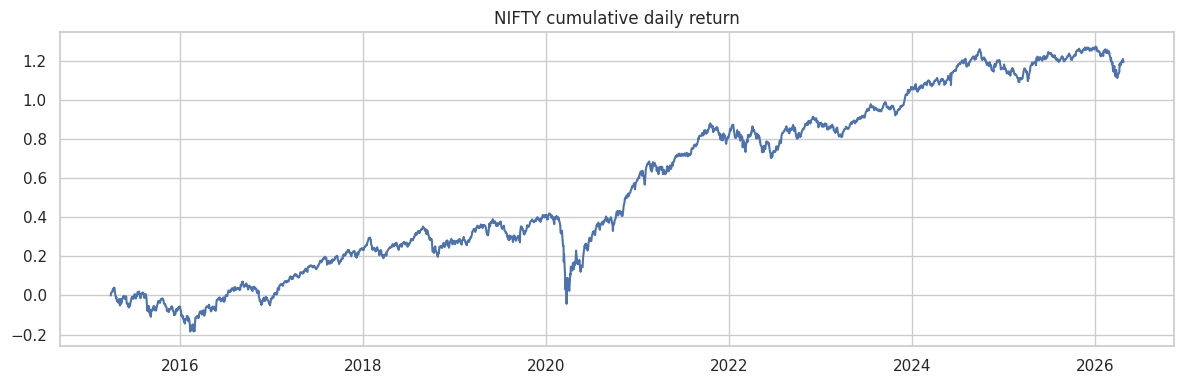

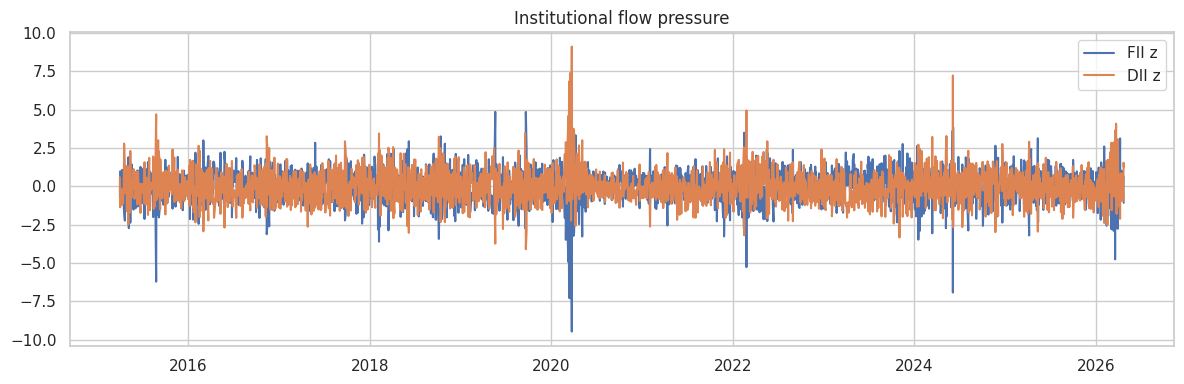

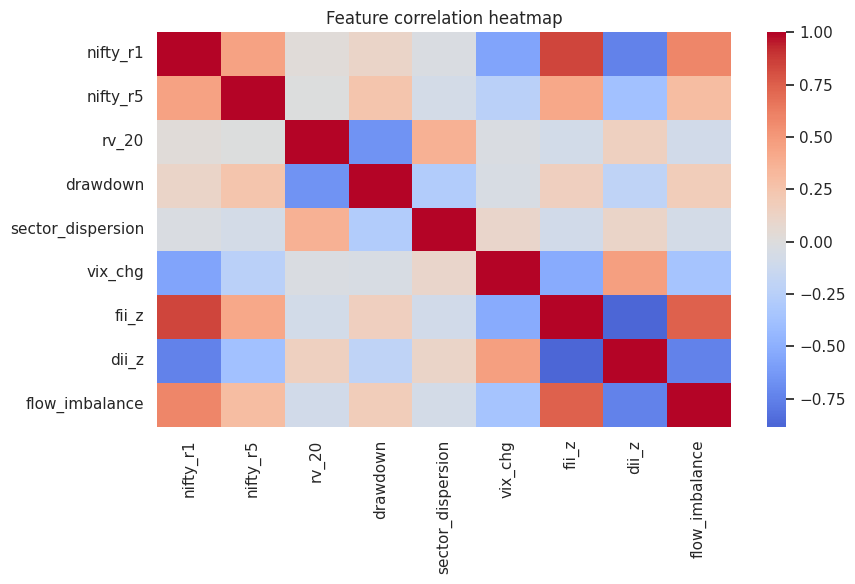

In [ ]:
display(daily.describe().T)
display(panel.groupby("sector")["downside"].mean().sort_values().to_frame("downside_rate"))

plt.figure(figsize = (12, 4))
plt.plot(daily["date"], daily["nifty_r1"].cumsum())
plt.title("NIFTY cumulative daily return")
plt.tight_layout()
plt.show()

plt.figure(figsize = (12, 4))
plt.plot(daily["date"], daily["fii_z"], label = "FII z")
plt.plot(daily["date"], daily["dii_z"], label = "DII z")
plt.title("Institutional flow pressure")
plt.legend()
plt.tight_layout()
plt.show()

heat_cols = ["nifty_r1", "nifty_r5", "rv_20", "drawdown", "sector_dispersion", "vix_chg", "fii_z", "dii_z", "flow_imbalance"]
plt.figure(figsize = (9, 6))
sns.heatmap(daily[heat_cols].corr(), center = 0, cmap = "coolwarm", annot = False)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

## Section 4
## Features set and Modelling Metrics

This cell defines the predictor sets used in the first modelling stage. The `base_cols` variables contain conventional market, volatility, drawdown, sector and institutional-flow features. The `game_cols` variables encode the FII--DII strategic interaction, such as joint buying, joint selling, domestic absorption and contested positioning.

The baseline feature vector is

$$
X^{base}_{s,t}
=
[
r^{NIFTY}_{t},
r^{NIFTY}_{t-5:t},
RV_{20,t},
DD_t,
Disp_t,
\Delta VIX_t,
FII^z_t,
DII^z_t,
FlowImb_t,
r_{s,t},
r_{s,t-5:t}
],
$$

while the full feature vector augments this with game-theoretic variables:

$$
X^{full}_{s,t}
=
[X^{base}_{s,t},G_t].
$$

The design-matrix objects standardise and transform the raw panel variables into numerical matrices for model fitting:

$$
X_{train}, X_{test}, y_{train}, y_{test}.
$$

The classification target is the future downside indicator,

$$
y_{s,t+h} \in \{0,1\},
$$

and `ret_fwd_5` is kept separately as the realised five-day forward return for regression and strategy evaluation.

The printed train and test event rates are important diagnostics. They show the empirical frequency of downside events in each sample:

$$
\hat{p}_{train} = \frac{1}{n_{train}}\sum_i y_i,
\qquad
\hat{p}_{test} = \frac{1}{n_{test}}\sum_i y_i.
$$

If these rates differ substantially, the out-of-sample test period has a different risk environment from the training period, which should be discussed when interpreting model performance.

In [ ]:
base_cols = ["nifty_r1", "nifty_r5", "rv_20", "drawdown", "sector_dispersion",
             "vix_chg", "fii_z", "dii_z", "flow_imbalance", "sector_r1", "sector_r5"]
game_cols = ["fii_action", "dii_action", "joint_buy", "joint_sell",
             "absorption", "contested", "action_alignment"]
all_cols = base_cols + game_cols

dm_base = DesignMatrix(base_cols)
X_train_base = dm_base.fit_transform(train)
X_test_base = dm_base.transform(test)

dm_all = DesignMatrix(all_cols)
X_train_all = dm_all.fit_transform(train)
X_test_all = dm_all.transform(test)

y_train = train["downside"].values
y_test = test["downside"].values
r_train = train["ret_fwd_5"].values
r_test = test["ret_fwd_5"].values

print(train.shape, test.shape)
print("Train event rate:", y_train.mean())
print("Test event rate:", y_test.mean())

(16376, 29) (5448, 29)
Train event rate: 0.20029311187103077
Test event rate: 0.1749265785609398


## Section 5.1
## Baseline return regression: OLS

This cell estimates the first benchmark model using ordinary least squares. The target is the realised five-day forward sector return,

$$
r_{s,t+5},
$$

and the predictors are the baseline market and sector features in \(X^{base}_{s,t}\). The model is

$$
r_{s,t+5}
=
\alpha
+
(X^{base}_{s,t})^\top \beta
+
\epsilon_{s,t},
$$

where \(\beta\) measures the linear association between current market conditions and future sector returns.

OLS estimates the coefficient vector by minimising squared prediction errors on the training set:

$$
\hat{\beta}_{OLS}
=
\arg\min_{\beta}
\sum_{i=1}^{n}
\left(r_i - X_i^\top \beta\right)^2.
$$

This model is deliberately simple. It tests whether the conventional market variables alone — returns, realised volatility, drawdown, sector dispersion, VIX changes and institutional-flow pressure — contain linear predictive information for next-week sector returns.

The evaluation is performed on the chronological test set using regression metrics such as RMSE, MAE and \(R^2\). This gives a baseline level of return-prediction performance against which later models are judged. In particular, the later Bayesian, game-regime and machine-learning models must show that they add value beyond this simple linear benchmark rather than merely fitting noise.

In [ ]:
ols = LinearRegression().fit(X_train_base, r_train)
ols_pred = ols.predict(X_test_base)
ols_metrics = ModelMetrics.regression(r_test, ols_pred)
display(pd.DataFrame([ols_metrics], index = ["OLS"]))

,MAE,RMSE,R2,DA
OLS,0.021542,0.029001,-0.023473,0.500551


## Section 5.2
## Regularised return baselines: Ridge and Lasso

This cell extends the OLS return-regression benchmark by adding two regularised linear models: Ridge and Lasso. The target remains the realised five-day forward sector return,

$$
r_{s,t+5},
$$

and the predictors remain the baseline feature set \(X^{base}_{s,t}\). The purpose is to test whether simple linear return prediction improves once coefficient size and overfitting are controlled.

Ridge regression estimates

$$
\hat{\beta}_{Ridge}
=
\arg\min_{\beta}
\left[
\sum_{i=1}^{n}
\left(r_i - X_i^\top \beta\right)^2
+
\lambda \sum_{j=1}^{p}\beta_j^2
\right].
$$

The \(L_2\) penalty shrinks coefficients towards zero but usually keeps all predictors in the model. This tests whether the baseline market and flow variables contain weak but distributed predictive information.

Lasso regression estimates

$$
\hat{\beta}_{Lasso}
=
\arg\min_{\beta}
\left[
\sum_{i=1}^{n}
\left(r_i - X_i^\top \beta\right)^2
+
\lambda \sum_{j=1}^{p}|\beta_j|
\right].
$$

The \(L_1\) penalty can shrink some coefficients exactly to zero, so it acts as a simple feature-selection benchmark. This is useful because financial predictors are often noisy and many may carry little incremental signal.

The table compares OLS, Ridge and Lasso on the same chronological test set. If Ridge or Lasso improves RMSE/MAE relative to OLS, it suggests that the return-prediction problem benefits from regularisation. If all three perform similarly, it indicates that next-week sector returns are difficult to forecast with a purely linear model, motivating the later shift towards downside-risk classification, Bayesian uncertainty modelling and game-regime features.

In [ ]:
ridge = Ridge(alpha = 1.0).fit(X_train_base, r_train)
lasso = Lasso(alpha = 0.0005, max_iter = 20000).fit(X_train_base, r_train)
ridge_metrics = ModelMetrics.regression(r_test, ridge.predict(X_test_base))
lasso_metrics = ModelMetrics.regression(r_test, lasso.predict(X_test_base))
regression_table = pd.DataFrame(
    [ols_metrics, ridge_metrics, lasso_metrics], index = ["OLS", "Ridge", "Lasso"]
)
display(regression_table)

,MAE,RMSE,R2,DA
OLS,0.021542,0.029001,-0.023473,0.500551
Ridge,0.021542,0.029001,-0.023464,0.500551
Lasso,0.021327,0.028752,-0.005959,0.527166


## Section 5.3
## Baseline downside classifier: Logistic regression

This cell estimates the first benchmark classifier for the downside-risk task. Instead of predicting the exact future return, the target is now the binary downside indicator,

$$
y_{s,t+5} \in \{0,1\},
$$

where \(y_{s,t+5}=1\) means that sector \(s\) enters the downside class over the next five trading days.

The logistic model estimates the conditional probability of a downside event using the baseline feature set:

$$
P(y_{s,t+5}=1 \mid X^{base}_{s,t}) = p_{s,t}.
$$

The model is written as

$$
\mathrm{logit}(p_{s,t})
=
\log\left(\frac{p_{s,t}}{1-p_{s,t}}\right)
=
\alpha + (X^{base}_{s,t})^\top \beta.
$$

Equivalently,

$$
p_{s,t}
=
\frac{1}{1+\exp[-(\alpha + (X^{base}_{s,t})^\top \beta)]}.
$$

This baseline tests whether conventional market, sector, volatility and institutional-flow variables can distinguish high-risk sector-days from normal sector-days. The model uses `class_weight="balanced"` because downside events are less frequent than non-downside observations. This prevents the classifier from simply favouring the majority class.

The predicted probabilities are evaluated using log loss, Brier score, AUC, PR-AUC, precision, recall, F1 score and top-decile lift. In this project, log loss and Brier score are especially important because the output is a probability forecast rather than just a hard class label. The logistic model therefore provides the main benchmark for later Bayesian classifiers, game-regime models and nonlinear machine-learning models.

In [ ]:
logit = LogisticRegression(max_iter = 3000).fit(X_train_base, y_train)
logit_p = logit.predict_proba(X_test_base)[:, 1]
logit_metrics = ModelMetrics.classification(y_test, logit_p, threshold = 0.5)
display(pd.DataFrame([logit_metrics], index = ["Logistic"]))

# Verify the classifier is not degenerate
recall_val = logit_metrics["Recall"]
if recall_val > 0.95:
    print(f"⚠ WARNING: Recall = {recall_val:.3f} — classifier may be predicting all positives. Check threshold.")
else:
    print(f"✓ Recall = {recall_val:.3f} — classifier is discriminating.")

,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
Logistic,0.467614,0.145717,0.82489,0.0,0.0,0.0,0.174927,0.497685,0.175293,1.143337


✓ Recall = 0.000 — classifier is discriminating.


## Section 5.4
## Nonlinear downside classifier: XGBoost

This cell estimates a stronger nonlinear benchmark for the downside-risk task using XGBoost. The target remains the binary five-day downside indicator,

$$
y_{s,t+5} \in \{0,1\},
$$

but unlike the logistic baseline, XGBoost is fitted on the full feature set,

$$
X^{full}_{s,t} = [X^{base}_{s,t}, G_t],
$$

where \(X^{base}_{s,t}\) contains market, volatility, sector and flow variables, and \(G_t\) contains the FII--DII game-theoretic interaction variables.

XGBoost builds an additive ensemble of decision trees:

$$
\hat{p}_{s,t}
=
\sigma\left(
\sum_{m=1}^{M} f_m(X^{full}_{s,t})
\right),
$$

where each \(f_m\) is a regression tree and \(\sigma(\cdot)\) maps the output into a probability. The model is trained sequentially, with each new tree attempting to correct the errors left by the previous trees.

The objective is approximately

$$
\mathcal{L}
=
\sum_i \ell(y_i,\hat{p}_i)
+
\sum_{m=1}^{M}\Omega(f_m),
$$

where \(\ell(\cdot)\) is the log-loss classification objective and \(\Omega(f_m)\) penalises tree complexity. This regularisation is important because financial predictors are noisy and nonlinear models can overfit easily.

The `scale_pos_weight` parameter adjusts for class imbalance by giving more weight to downside events, which are less frequent than normal observations. The model therefore tests whether nonlinear interactions between institutional flows, volatility, sector momentum and game variables improve downside-risk classification beyond the linear logistic benchmark.

This is an important comparison model. If XGBoost performs better than the Bayesian models, the interpretation is not that the Bayesian approach has failed; rather, it suggests that nonlinear predictive structure exists, while the Bayesian models contribute uncertainty quantification and interpretability.

In [ ]:
spw = max(1, sum(y_train == 0) / max(1, sum(y_train == 1)))
xgb = XGBClassifier(
    n_estimators = 250, max_depth = 3, learning_rate = 0.04,
    subsample = 0.85, colsample_bytree = 0.85,
    scale_pos_weight = spw, eval_metric = "logloss",
    random_state = cfg.random_state,
)
xgb.fit(X_train_all, y_train)
xgb_p = xgb.predict_proba(X_test_all)[:, 1]
xgb_metrics = ModelMetrics.classification(y_test, xgb_p, threshold = y_train.mean())
display(pd.DataFrame([xgb_metrics], index = ["XGBoost"]))

,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
XGBoost,0.621206,0.215593,0.188693,0.177128,0.997901,0.300854,0.174927,0.557636,0.19721,1.059422


## Section 5.5
## Regularised return baselines: Ridge and Lasso

This cell extends the OLS return-regression benchmark with two regularised linear models: Ridge and Lasso. The target remains the realised five-day forward sector return,

$$
r_{s,t+5},
$$

and the predictors remain the baseline feature set \(X^{base}_{s,t}\). The purpose is to test whether simple linear return forecasting improves once unstable coefficients are penalised.

Ridge regression solves

$$
\hat{\beta}_{Ridge}
=
\arg\min_{\beta}
\left[
\sum_{i=1}^{n}
(r_i - X_i^\top\beta)^2
+
\lambda \sum_{j=1}^{p}\beta_j^2
\right].
$$

The \(L_2\) penalty shrinks coefficients towards zero but usually keeps all variables active. This tests whether the market, volatility, sector and institutional-flow predictors contain weak but distributed predictive information.

Lasso regression solves

$$
\hat{\beta}_{Lasso}
=
\arg\min_{\beta}
\left[
\sum_{i=1}^{n}
(r_i - X_i^\top\beta)^2
+
\lambda \sum_{j=1}^{p}|\beta_j|
\right].
$$

The \(L_1\) penalty can shrink some coefficients exactly to zero, so it acts as a simple feature-selection benchmark. This is useful in financial prediction because many candidate predictors may be noisy or redundant.

The table compares OLS, Ridge and Lasso on the same chronological test set. This baseline section tests whether next-week sector returns are linearly predictable at all before moving to the main downside-risk classification models. If the regularised models only marginally improve on OLS, that motivates the later shift from exact return prediction to probabilistic downside-risk forecasting.

,MAE,RMSE,R2,DA
Bayesian Ridge,0.021488,0.028943,-0.019385,0.506057


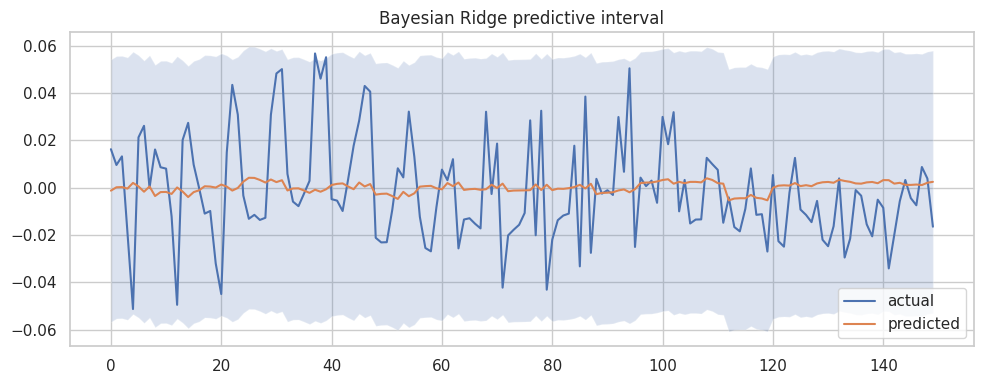

In [ ]:
bayes_ridge = BayesianRidge().fit(X_train_base, r_train)
bayes_ridge_pred, bayes_ridge_std = bayes_ridge.predict(X_test_base, return_std = True)
bayes_ridge_metrics = ModelMetrics.regression(r_test, bayes_ridge_pred)
display(pd.DataFrame([bayes_ridge_metrics], index = ["Bayesian Ridge"]))

plt.figure(figsize = (10, 4))
plt.plot(r_test[:150], label = "actual")
plt.plot(bayes_ridge_pred[:150], label = "predicted")
plt.fill_between(
    np.arange(min(150, len(r_test))),
    bayes_ridge_pred[:150] - 1.64 * bayes_ridge_std[:150],
    bayes_ridge_pred[:150] + 1.64 * bayes_ridge_std[:150],
    alpha = 0.2,
)
plt.title("Bayesian Ridge predictive interval")
plt.legend()
plt.tight_layout()
plt.show()

## Section 5.6
## Bayesian downside classifier: Laplace logistic regression

This cell estimates a Bayesian version of the logistic downside classifier. The target is again the five-day downside indicator,

$$
y_{s,t+5} \in \{0,1\},
$$

and the predictors are the baseline feature set \(X^{base}_{s,t}\).

The model is

$$
y_{s,t+5} \sim \mathrm{Bernoulli}(p_{s,t}),
$$

with

$$
\mathrm{logit}(p_{s,t})
=
\alpha + (X^{base}_{s,t})^\top \beta.
$$

The Bayesian version places a prior on the coefficient vector:

$$
\beta \sim N(0,\tau^2 I).
$$

Because Bayesian logistic regression does not have a closed-form conjugate posterior, this implementation uses a Laplace approximation. First, the posterior mode is found through a regularised logistic regression fit. Then the posterior distribution is approximated by a multivariate normal distribution around that mode:

$$
p(\beta \mid \mathcal{D})
\approx
N(\hat{\beta}, H^{-1}),
$$

where \(H\) is the Hessian of the negative log posterior evaluated at the posterior mode.

Predicted probabilities are obtained by averaging over posterior coefficient draws:

$$
\hat{p}_{s,t}
=
\frac{1}{M}
\sum_{m=1}^{M}
\sigma\left(\alpha^{(m)} + (X^{base}_{s,t})^\top \beta^{(m)}\right),
$$

where \(\sigma(\cdot)\) is the logistic function and \(\beta^{(m)}\) are draws from the approximate posterior.

This model tests whether Bayesian uncertainty over the logistic coefficients improves probabilistic downside-risk forecasting relative to the plain logistic baseline. It is especially relevant because the project is not only interested in hard classifications, but in calibrated probabilities of future sector downside events.

In [ ]:
bayes_logit = BayesianLogisticLaplace(prior_var = 1.0, draws = 1000, random_state = cfg.random_state) # recommended by AI
bayes_logit.fit(X_train_base, y_train)
bayes_p = bayes_logit.predict_proba(X_test_base)[:, 1]
bayes_metrics = ModelMetrics.classification(y_test, bayes_p, threshold = y_train.mean())
display(pd.DataFrame([bayes_metrics], index = ["Bayesian Logistic Laplace"]))

,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
Bayesian Logistic Laplace,0.684713,0.245676,0.174927,0.174927,1.0,0.297766,0.174927,0.502305,0.175697,1.122358


## Section 5.7
## Hidden-state market regime layer

This cell introduces a latent market-regime model using a Gaussian Hidden Markov Model (HMM). The idea is that the observable market does not evolve under a single fixed environment. Instead, it switches between a small number of hidden states, here interpreted as **risk-on**, **contested**, and **stress** regimes.

The model is fitted on the training-period daily market data using the regime features

$$
X_t = [\text{nifty\_r1},\ \text{vix\_chg},\ \text{rv\_20},\ \text{drawdown},\ \text{fii\_z},\ \text{dii\_z},\ \text{flow\_imbalance}]_t.
$$

Formally, the HMM assumes an unobserved state variable \(z_t \in \{1,2,3\}\) evolving through time as a Markov chain:

$$
P(z_t = j \mid z_{t-1} = i) = \Pi_{ij},
$$

where \(\Pi\) is the transition matrix. Conditional on the current regime, the observed market features are assumed Gaussian:

$$
X_t \mid z_t = k \sim N(\mu_k, \Sigma_k).
$$

So the model jointly estimates:

1. the transition behaviour of regimes over time, and  
2. the characteristic market profile of each regime.

After fitting the model on `daily_train`, the code computes **filtered regime probabilities** for every day:

$$
P(z_t = k \mid X_{1:t}),
$$

which represent the probability that the market is in regime \(k\) using only information available up to time \(t\). These probabilities are then merged back into both the daily dataset and the sector panel, so they can later be used as regime-aware predictors in the game-theoretic and Bayesian layers.

The group means by `regime_label` are used to interpret the economic meaning of each latent state. For example, a regime with high volatility, adverse flow imbalance, weaker returns and stressed institutional behaviour can naturally be labelled **stress**, while a calmer lower-volatility state is interpreted as **risk-on**.

The plot of filtered hidden-regime probabilities provides a visual check of regime switching over time. Sharp movements towards one regime probability close to 1 indicate periods when the model sees the market environment as clearly dominated by a single state.

The mean regime entropy is a diagnostic of regime separation:

$$
H_t = -\sum_{k=1}^{K} p_{t,k}\log(p_{t,k}),
$$

where \(p_{t,k} = P(z_t=k \mid X_{1:t})\). Lower entropy means the model is assigning observations more confidently to one regime, while higher entropy indicates blurred or poorly separated states. The counts by regime then show how often each market state appears in the sample.

This layer is important because it tests whether downside risk and institutional interaction should be interpreted conditionally on the broader market environment rather than in isolation.

,nifty_r1,vix_chg,rv_20,drawdown,fii_z,dii_z,flow_imbalance
regime_label,,,,,,,
contested,0.000669,-0.002473,0.143583,-0.073301,0.039120,-0.044952,0.043561
risk_on,0.000442,0.002748,0.092600,-0.015232,0.037228,-0.081181,0.189445
stress,-0.000521,0.013688,0.285844,-0.117076,-0.285272,0.378490,-0.117542


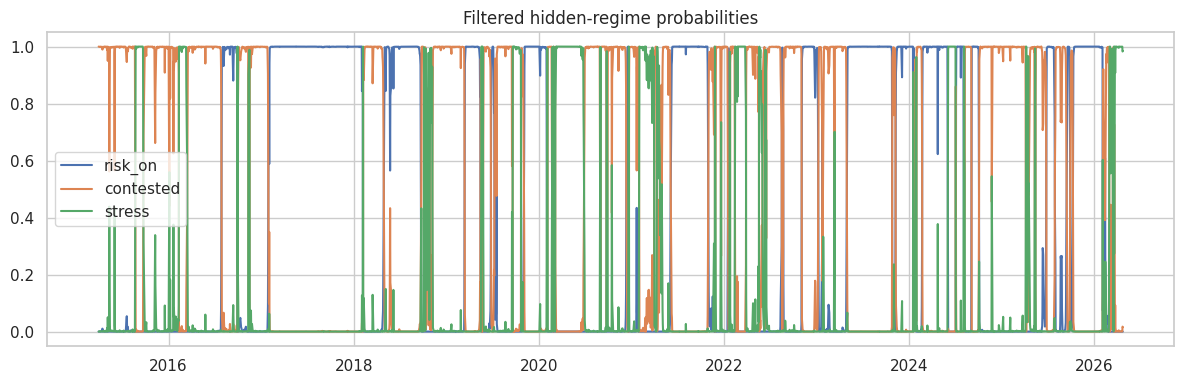

In [ ]:
regime_cols = ["nifty_r1", "vix_chg", "rv_20", "drawdown", "fii_z", "dii_z", "flow_imbalance"]
regime_model = MarketRegimeModel(n_regimes = 3, random_state = cfg.random_state).fit(daily_train, regime_cols)
regimes = regime_model.filtered_probabilities(daily)
daily_regime = daily.merge(regimes, on = "date", how = "left")
panel_regime = panel.merge(regimes, on = "date", how = "left")
regime_prob_cols = [c for c in panel_regime.columns
                    if c.startswith("regime_")
                    and c not in ("regime_label", "regime_entropy")]

display(daily_regime.groupby("regime_label")[regime_cols].mean())

plt.figure(figsize = (12, 4))
for lab in ["risk_on", "contested", "stress"]:
    plt.plot(daily_regime["date"], daily_regime[f"regime_{lab}"], label = lab)
plt.title("Filtered hidden-regime probabilities")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
regime_summary = daily_regime.groupby("regime_label")[
    ["nifty_r1", "vix_chg", "rv_20", "fii_z", "dii_z"]
].mean().round(4)
display(regime_summary)

mean_entropy = daily_regime["regime_entropy"].mean()
print(f"Mean regime entropy: {mean_entropy:.3f}")

if mean_entropy > 0.8:
    print("WARNING: Regimes are not well separated.")
else:
    print("Regimes look well separated.")

counts = daily_regime["regime_label"].value_counts()
total = len(daily_regime)
for label, n in counts.items():
    print(f"  {label}: {n} days ({n/total:.1%})")

,nifty_r1,vix_chg,rv_20,fii_z,dii_z
regime_label,,,,,
contested,0.0007,-0.0025,0.1436,0.0391,-0.0450
risk_on,0.0004,0.0027,0.0926,0.0372,-0.0812
stress,-0.0005,0.0137,0.2858,-0.2853,0.3785


Mean regime entropy: 0.064
Regimes look well separated.
  contested: 1336 days (49.0%)
  risk_on: 1062 days (38.9%)
  stress: 330 days (12.1%)


## Section 5.8
## Game-theoretic institutional response layer

This cell builds the game-theoretic layer of the project. The idea is to treat daily FII and DII flow behaviour as a repeated institutional interaction rather than as two unrelated predictors. Each institution is assigned a discrete action:

$$
a^{FII}_t, a^{DII}_t \in \{-1,0,1\},
$$

where \(-1\) represents net selling, \(0\) represents neutral flow, and \(1\) represents net buying.

The central object estimated here is the empirical response distribution:

$$
P(a^{DII}_t = j \mid a^{FII}_t = i),
$$

for \(i,j \in \{-1,0,1\}\). In words, the model asks: **when foreign institutions buy, sell, or remain neutral, how do domestic institutions tend to respond?**

This is where the game-theoretic structure enters the pipeline. The market is not treated as being driven only by one aggregate flow. Instead, the code measures the interaction between two strategic institutional groups. For example:

- \(FII=-1, DII=1\): foreign selling absorbed by domestic buying.
- \(FII=-1, DII=-1\): joint institutional selling, interpreted as stress.
- \(FII=1, DII=1\): coordinated institutional buying.
- \(FII=1, DII=-1\): contested positioning.

The `GameResponseLearner` estimates these conditional response probabilities from the training period and then applies them to the full daily dataset. This creates probability features such as

$$
P(a^{DII}_t = 1 \mid a^{FII}_t, z_t),
$$

and derived strategic-risk variables such as

$$
\text{Domestic Absorption}_t
=
\mathbf{1}(a^{FII}_t=-1)
\cdot
P(a^{DII}_t=1),
$$

and

$$
\text{Joint Stress}_t
=
\mathbf{1}(a^{FII}_t=-1)
\cdot
P(a^{DII}_t=-1).
$$

These variables are then merged into the sector panel, so the later downside-risk models can test whether institutional interaction helps forecast future sector losses.

The response table and heatmap provide the empirical check. In the displayed result, when FIIs sell, DIIs are often observed buying; this supports the interpretation of domestic absorption. Conversely, when both groups move in the same selling direction, the model treats this as a stronger risk signal. The point is not to claim a formal Nash equilibrium, but to encode a repeated strategic pattern in the data and test whether it improves downside-risk forecasting.

dii_action,-1,0,1
fii_action,,,
-1,0.000000,0.255287,0.744713
0,0.160363,0.709531,0.130106
1,0.733871,0.263441,0.002688


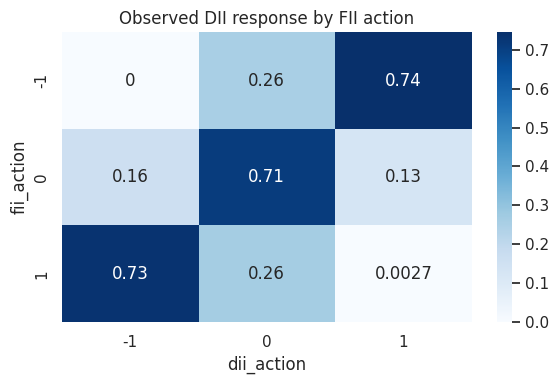

In [ ]:
daily_train_r, daily_test_r = builder.split(daily_regime, cut)
response_learner = GameResponseLearner().fit(daily_train_r)
daily_game = response_learner.transform(daily_regime)
panel_game = panel_regime.merge(
    daily_game[["date", "p_dii_sell_resp", "p_dii_neutral_resp",
                "p_dii_buy_resp", "p_domestic_absorption", "p_joint_stress"]],
    on = "date", how = "left",
)

response_table = pd.crosstab(daily_game["fii_action"], daily_game["dii_action"], normalize = "index")
display(response_table)

plt.figure(figsize = (6, 4))
sns.heatmap(response_table, annot = True, cmap = "Blues")
plt.title("Observed DII response by FII action")
plt.tight_layout()
plt.show()

## Section 5.9
## Bayesian game-regime downside classifier

This cell combines the main components developed so far into a single Bayesian downside-risk classifier. The model uses three groups of predictors:

1. baseline market, volatility, sector and flow variables;
2. filtered hidden-regime probabilities from the HMM;
3. game-theoretic institutional-response variables from the FII--DII layer.

The final feature vector is

$$
X^{game-regime}_{s,t}
=
[
X^{base}_{s,t},
G_t,
Z_t,
R_t
],
$$

where \(G_t\) contains direct FII--DII action variables, \(Z_t\) contains filtered regime probabilities such as \(P(z_t=\text{stress}\mid X_{1:t})\), and \(R_t\) contains learned DII response probabilities such as \(P(a^{DII}_t=-1\mid a^{FII}_t,z_t)\).

The classifier is a Bayesian logistic model:

$$
y_{s,t+5} \sim \mathrm{Bernoulli}(p_{s,t}),
$$

with

$$
\mathrm{logit}(p_{s,t})
=
\alpha
+
(X^{game-regime}_{s,t})^\top \beta.
$$

A normal prior is placed on the coefficients,

$$
\beta \sim N(0,\tau^2 I),
$$

and posterior uncertainty is approximated using the Laplace method. This gives an approximate posterior distribution

$$
p(\beta \mid \mathcal{D}_{train})
\approx
N(\hat{\beta}, H^{-1}),
$$

where \(\hat{\beta}\) is the posterior mode and \(H\) is the Hessian of the negative log posterior.

Predicted downside probabilities are obtained by averaging over posterior coefficient draws:

$$
\hat{p}_{s,t}
=
\frac{1}{M}
\sum_{m=1}^{M}
\sigma\left(
\alpha^{(m)}
+
(X^{game-regime}_{s,t})^\top \beta^{(m)}
\right).
$$

This model tests the central empirical claim of the project: whether downside risk is better explained when market variables are augmented with latent regime information and institutional strategic interaction. In practical terms, it asks whether a sector is more likely to experience a future loss when the market is in a stressed hidden state and the FII--DII response pattern indicates weak domestic absorption or joint institutional selling.

The output table evaluates the model on the chronological test set using probabilistic classification metrics. The most important metrics are log loss and Brier score, because the purpose of this model is not only to classify events but to produce calibrated posterior downside-risk probabilities.

In [ ]:
train_r, test_r = builder.split(panel_game.dropna(), cut)
response_cols = ["p_dii_sell_resp", "p_dii_buy_resp"]
full_cols = all_cols + regime_prob_cols + response_cols

dm_full = DesignMatrix(full_cols)
X_train_full = dm_full.fit_transform(train_r)
X_test_full = dm_full.transform(test_r)
y_train_r = train_r["downside"].values
y_test_r = test_r["downside"].values

bayes_game = BayesianLogisticLaplace(prior_var = 1.0, draws = 1000, random_state = cfg.random_state)
bayes_game.fit(X_train_full, y_train_r)
bayes_game_train_p = bayes_game.predict_proba(X_train_full)[:, 1]
bayes_game_p = bayes_game.predict_proba(X_test_full)[:, 1]
bayes_game_metrics = ModelMetrics.classification(y_test_r, bayes_game_p, threshold = y_train_r.mean())
display(pd.DataFrame([bayes_game_metrics], index = ["Bayesian Game-Regime Laplace"]))

,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
Bayesian Game-Regime Laplace,0.682573,0.244499,0.174927,0.174927,1.0,0.297766,0.174927,0.516131,0.1787,1.048933


## Section 5.9
## Advanced Bayesian model: hierarchical game-regime logistic regression

This cell estimates the main advanced Bayesian model in the project. The target is the five-day sector downside indicator,

$$
y_{s,t+5} \in \{0,1\},
$$

and the predictors include market variables, FII--DII game variables, filtered regime probabilities and learned institutional-response probabilities.

The model is a hierarchical Bayesian logistic regression:

$$
y_{s,t+5} \sim \mathrm{Bernoulli}(p_{s,t}),
$$

with

$$
\mathrm{logit}(p_{s,t})
=
\alpha_s
+
X_{s,t}^{\top}\beta.
$$

Here, \(\alpha_s\) is a sector-specific intercept and \(\beta\) is the coefficient vector for the full game-regime feature set. The sector intercepts are partially pooled through a hierarchical prior:

$$
\alpha_s \sim N(\mu_\alpha,\sigma_\alpha^2).
$$

This is important because different sectors have different baseline downside-risk levels, but the model should still share information across sectors rather than estimating each sector independently.

The coefficient vector is given a Bayesian shrinkage prior:

$$
\beta_j \sim N(0,\tau^2\lambda_j^2),
$$

where \(\tau\) controls global shrinkage and \(\lambda_j\) controls local feature-level shrinkage. This is useful because the full feature set contains many noisy financial predictors, and the model should shrink weak predictors while allowing stronger game-regime effects to remain active.

Posterior inference is performed using PyMC. Instead of producing only one fitted coefficient vector, the model samples from the posterior distribution:

$$
p(\alpha,\beta,\mu_\alpha,\sigma_\alpha,\tau \mid \mathcal{D}_{train}).
$$

Predicted downside probabilities are then computed by averaging across posterior draws:

$$
\hat{p}_{s,t}
=
\frac{1}{M}
\sum_{m=1}^{M}
\sigma
\left(
\alpha_s^{(m)}
+
X_{s,t}^{\top}\beta^{(m)}
\right).
$$

This model tests whether the combination of Bayesian partial pooling, institutional-flow interaction and hidden-regime information improves probabilistic downside-risk forecasting. It is the most explicitly Bayesian model in the notebook because it produces posterior uncertainty, sector-specific risk effects and coefficient credible intervals.

In [ ]:
n_full = len(train_r)
n_cap  = cfg.pymc_max_rows
pct    = 100 * min(n_cap, n_full) / n_full
print(f"ℹ PyMC model will be fitted on {min(n_cap, n_full):,} of {n_full:,} "
      f"training rows ({pct:.1f}%) due to pymc_max_rows = {n_cap}.")
print(f"This is computational constraint disclosed here and in Section 3.8 of the report.\n")

pymc_model = PyMCHierarchicalGameModel(cfg)
pymc_model.fit(train_r, full_cols)

pymc_train_p = pymc_model.predict_proba(train_r)
pymc_p = pymc_model.predict_proba(test_r)

valid = ~np.isnan(pymc_p)
pymc_metrics = ModelMetrics.classification(y_test_r[valid], pymc_p[valid], threshold = y_train_r.mean())
display(pd.DataFrame([pymc_metrics], index = ["PyMC Hierarchical Game-Regime Shrinkage"]))

ℹ PyMC model will be fitted on 6,000 of 16,376 training rows (36.6%) due to pymc_max_rows = 6000.
This is computational constraint disclosed here and in Section 3.8 of the report.



Output()

ERROR:pymc.stats.convergence:There were 508 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
PyMC Hierarchical Game-Regime Shrinkage,0.678795,0.242759,0.174927,0.174927,1.0,0.297766,0.174927,0.521023,0.188004,1.143337


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,0.001,0.031,-0.053,0.059,0.001,0.001,2117.200,1844.486,1.001
sigma_alpha,0.035,0.030,0.000,0.087,0.001,0.001,1232.690,1191.305,1.007
tau,0.046,0.024,0.011,0.090,0.001,0.001,568.208,999.434,1.005


,feature,mean,sd,hdi_3%,hdi_97%,r_hat,ess_bulk
beta[regime_risk_on],regime_risk_on,-0.168,0.085,-0.299,0.015,1.004,420.315
beta[drawdown],drawdown,0.106,0.050,-0.001,0.189,1.002,1087.136
beta[sector_r5],sector_r5,-0.091,0.038,-0.162,-0.018,1.002,1714.008
beta[nifty_r1],nifty_r1,-0.061,0.053,-0.163,0.017,1.002,1168.793
beta[regime_stress],regime_stress,0.061,0.065,-0.027,0.204,1.004,403.315
beta[dii_z],dii_z,0.057,0.058,-0.023,0.170,1.003,1122.698
beta[rv_20],rv_20,0.042,0.045,-0.023,0.132,1.002,1110.426
beta[flow_imbalance],flow_imbalance,0.021,0.032,-0.027,0.092,1.001,1490.953
beta[p_dii_sell_resp],p_dii_sell_resp,0.020,0.041,-0.043,0.113,1.003,1167.566
beta[contested],contested,-0.019,0.039,-0.106,0.041,1.006,804.364


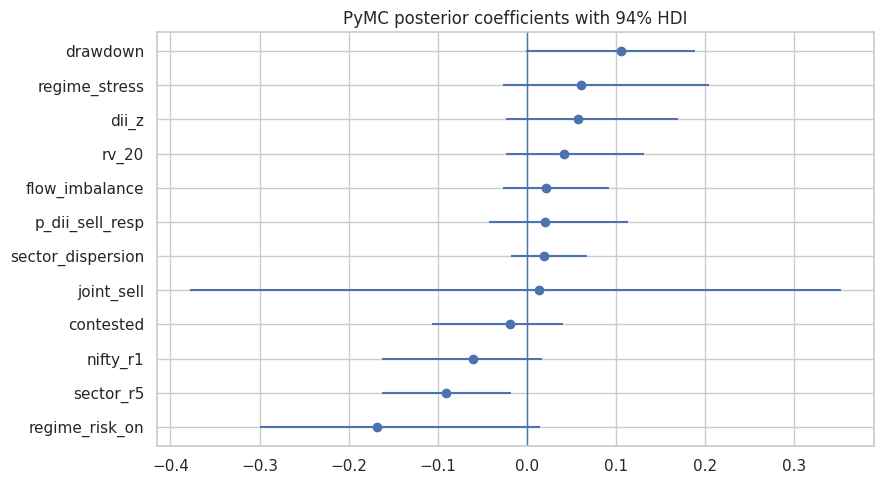

In [ ]:
display(az.summary(pymc_model.idata, var_names = ["mu_alpha", "sigma_alpha", "tau"], round_to = 3))
coef_summary = pymc_model.coefficient_summary()
display(coef_summary.head(15))

plot_df = coef_summary.head(12).sort_values("mean")
plt.figure(figsize = (9, 5))
plt.errorbar(
    plot_df["mean"], plot_df["feature"],
    xerr = [plot_df["mean"] - plot_df["hdi_3%"], plot_df["hdi_97%"] - plot_df["mean"]],
    fmt = "o",
)
plt.axvline(0, linewidth = 1)
plt.title("PyMC posterior coefficients with 94% HDI")
plt.tight_layout()
plt.show()

,max_rhat,min_ess_bulk,min_ess_tail,divergences,mean_acceptance_rate
0,1.018,395.773,209.844,508,0.87261


,feature,mean,sd,hdi_3%,hdi_97%,r_hat,ess_bulk
beta[regime_risk_on],regime_risk_on,-0.168,0.085,-0.299,0.015,1.004,420.315
beta[drawdown],drawdown,0.106,0.050,-0.001,0.189,1.002,1087.136
beta[sector_r5],sector_r5,-0.091,0.038,-0.162,-0.018,1.002,1714.008
beta[nifty_r1],nifty_r1,-0.061,0.053,-0.163,0.017,1.002,1168.793
beta[regime_stress],regime_stress,0.061,0.065,-0.027,0.204,1.004,403.315
beta[dii_z],dii_z,0.057,0.058,-0.023,0.170,1.003,1122.698
beta[rv_20],rv_20,0.042,0.045,-0.023,0.132,1.002,1110.426
beta[flow_imbalance],flow_imbalance,0.021,0.032,-0.027,0.092,1.001,1490.953
beta[p_dii_sell_resp],p_dii_sell_resp,0.020,0.041,-0.043,0.113,1.003,1167.566
beta[contested],contested,-0.019,0.039,-0.106,0.041,1.006,804.364


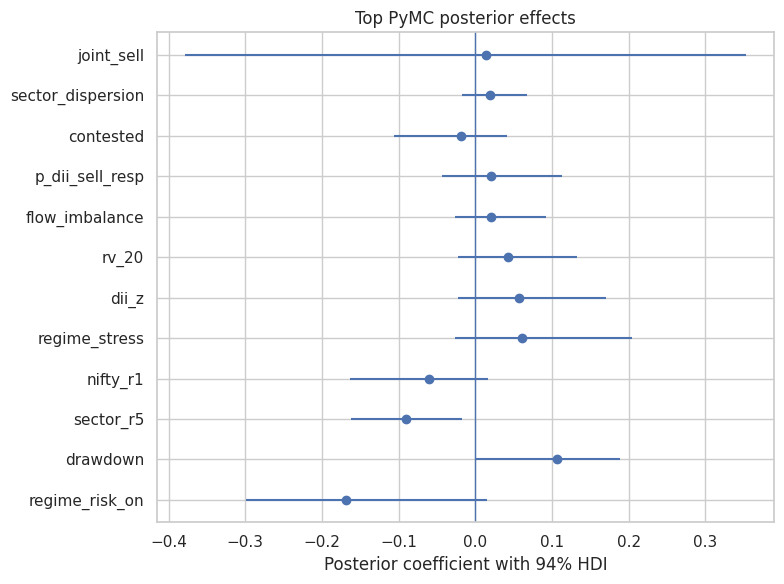

In [ ]:
def pymc_diagnostics(idata):
    summary = az.summary(idata, round_to = 3)
    out = {
        "max_rhat": summary["r_hat"].max() if "r_hat" in summary.columns else np.nan,
        "min_ess_bulk": summary["ess_bulk"].min() if "ess_bulk" in summary.columns else np.nan,
        "min_ess_tail": summary["ess_tail"].min() if "ess_tail" in summary.columns else np.nan,
        "divergences": int(idata.sample_stats["diverging"].sum().values) if "diverging" in idata.sample_stats else np.nan,
        "mean_acceptance_rate": float(idata.sample_stats["acceptance_rate"].mean().values) if "acceptance_rate" in idata.sample_stats else np.nan,
    }
    return pd.DataFrame([out])


pymc_diag = pymc_diagnostics(pymc_model.idata)
display(pymc_diag)

coef_table = pymc_model.coefficient_summary()
display(coef_table.head(20))

top_coef = coef_table.head(12).copy()
plt.figure(figsize = (8, 6))
plt.errorbar(
    top_coef["mean"],
    np.arange(len(top_coef)),
    xerr = [top_coef["mean"] - top_coef["hdi_3%"], top_coef["hdi_97%"] - top_coef["mean"]],
    fmt = "o",
)
plt.axvline(0, linewidth = 1)
plt.yticks(np.arange(len(top_coef)), top_coef["feature"])
plt.xlabel("Posterior coefficient with 94% HDI")
plt.title("Top PyMC posterior effects")
plt.tight_layout()
plt.show()

## Section 6
## Additional benchmark models and fair model comparison

This section evaluates the Bayesian game-regime models against stronger nonlinear machine-learning benchmarks. The purpose is not to make the Bayesian model compete only against weak baselines, but to test it against models that can capture nonlinearities, threshold effects and feature interactions in the full game-regime feature set.

The full feature matrix is

$$
X^{full}_{s,t}
=
[
X^{base}_{s,t},
G_t,
Z_t,
R_t
],
$$

where \(X^{base}_{s,t}\) contains market, sector, volatility and flow predictors, \(G_t\) contains direct FII--DII action variables, \(Z_t\) contains filtered HMM regime probabilities, and \(R_t\) contains learned DII response probabilities.

The benchmark classifiers estimate

$$
\hat{p}_{s,t}
=
P(y_{s,t+5}=1 \mid X^{full}_{s,t}),
$$

where \(y_{s,t+5}=1\) denotes a future sector downside event. The models are evaluated using probabilistic classification metrics, especially log loss and Brier score, because this project is primarily interested in calibrated downside-risk probabilities rather than only hard class labels.

XGBoost and histogram gradient boosting are included because they can approximate nonlinear functions of the predictors:

$$
\hat{p}_{s,t}
=
\sigma\left(
\sum_{m=1}^{M} f_m(X^{full}_{s,t})
\right),
$$

where each \(f_m\) is a regression tree. Random Forest and Extra Trees provide ensemble-tree alternatives based on averaging many decorrelated trees:

$$
\hat{p}_{s,t}
=
\frac{1}{B}
\sum_{b=1}^{B}
\hat{p}^{(b)}_{s,t}.
$$

The tree models are calibrated using isotonic calibration, so their probability outputs are adjusted to better match observed downside frequencies. This matters because an uncalibrated classifier can have good ranking power but poor probability estimates.

The Gaussian Process classifier is included only when the training set is small enough to make computation feasible. It represents a Bayesian non-parametric benchmark, where the latent classification function is modelled as

$$
f(\cdot) \sim GP(0, K),
$$

with a kernel combining smooth nonlinear similarity and a linear component.

The model comparison is deliberately split into two tables. The first table compares all available models, while the second separates:

1. **base-feature models**, which use only conventional market, sector, volatility and flow predictors;
2. **full-feature models**, which additionally use game-theoretic response variables and filtered regime probabilities.

This separation is important for fairness. A base logistic model should not be judged as if it had access to the same information as a full game-regime classifier. The full-feature comparison therefore answers the sharper question:

> Given the same game-regime information, do Bayesian models, boosted trees, random forests or Gaussian processes produce the best downside-risk probabilities?

If the nonlinear tree models outperform the Bayesian models on log loss or Brier score, the interpretation is that nonlinear predictive structure exists in the full feature set. If the Bayesian models remain competitive, their advantage is that they also provide posterior uncertainty, hierarchical sector pooling and interpretable coefficient effects. The strongest empirical conclusion therefore comes not from one model winning every metric, but from comparing predictive accuracy, probability calibration and interpretability across model classes.

In [ ]:
xgb_full = XGBClassifier(
    n_estimators = 250, max_depth = 3, learning_rate = 0.04,
    subsample = 0.85, colsample_bytree = 0.85,
    scale_pos_weight = spw, eval_metric = "logloss",
    random_state = cfg.random_state,
)
xgb_full.fit(X_train_full, y_train_r)
xgb_p_full = xgb_full.predict_proba(X_test_full)[:, 1]
xgb_metrics_full = ModelMetrics.classification(y_test_r, xgb_p_full, threshold = y_train_r.mean())

In [ ]:
rf = CalibratedClassifierCV(
    RandomForestClassifier(n_estimators = 300, max_depth = 6,
                           class_weight = "balanced", random_state = cfg.random_state),
    method = "isotonic", cv = 3,
)
rf.fit(X_train_full, y_train_r)
rf_p = rf.predict_proba(X_test_full)[:, 1]
rf_metrics = ModelMetrics.classification(y_test_r, rf_p, threshold = y_train_r.mean())

extra = CalibratedClassifierCV(
    ExtraTreesClassifier(n_estimators = 400, max_depth = 8,
                         class_weight = "balanced", random_state = cfg.random_state),
    method = "isotonic", cv = 3,
)
extra.fit(X_train_full, y_train_r)
extra_p = extra.predict_proba(X_test_full)[:, 1]
extra_metrics = ModelMetrics.classification(y_test_r, extra_p, threshold = y_train_r.mean())

hgb = CalibratedClassifierCV(
    HistGradientBoostingClassifier(max_iter = 250, learning_rate = 0.04,
                                   max_leaf_nodes = 15, random_state = cfg.random_state),
    method = "isotonic", cv = 3,
)
hgb.fit(X_train_full, y_train_r)
hgb_p = hgb.predict_proba(X_test_full)[:, 1]
hgb_metrics = ModelMetrics.classification(y_test_r, hgb_p, threshold = y_train_r.mean())

if len(X_train_full) <= 4000:
    gpc = GaussianProcessClassifier(kernel = RBF() + DotProduct(), random_state = cfg.random_state)
    gpc.fit(X_train_full, y_train_r)
    gpc_p = gpc.predict_proba(X_test_full)[:, 1]
    gpc_metrics = ModelMetrics.classification(y_test_r, gpc_p, threshold = y_train_r.mean())
else:
    gpc_metrics = pd.Series({k: np.nan for k in bayes_game_metrics.index})

forecast_table = pd.DataFrame(
    [logit_metrics, bayes_metrics, bayes_game_metrics, pymc_metrics,
     xgb_metrics, rf_metrics, extra_metrics, hgb_metrics, gpc_metrics],
    index = ["Logistic", "Bayesian Logistic Laplace", "Bayesian Game-Regime Laplace",
         "PyMC Hierarchical Game-Regime shrinkage", "XGBoost",
         "Random Forest calibrated", "Extra Trees calibrated", "Hist Gradient Boosting calibrated",
         "Gaussian Process"]
)
display(forecast_table.sort_values("LogLoss"))

###

base_table = pd.DataFrame(
    [logit_metrics, bayes_metrics],
    index=["Logistic (base features)", "Bayesian Logistic Laplace (base features)"],
)
print("--- Base feature models ---")
display(base_table.sort_values("LogLoss"))

# Full features — fair within-feature-set comparison
full_table = pd.DataFrame(
    [bayes_game_metrics, pymc_metrics, xgb_metrics_full,
     rf_metrics, extra_metrics, hgb_metrics, gpc_metrics],
    index=["Bayesian Game-Regime Laplace", "PyMC Hierarchical Horseshoe",
           "XGBoost", "Random Forest calibrated",
           "Extra Trees calibrated", "Hist Gradient Boosting calibrated",
           "Gaussian Process"],
)
print("--- Full feature models ---")
display(full_table.sort_values("LogLoss"))


,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
Random Forest calibrated,0.464695,0.144700,0.520558,0.176356,0.474292,0.257110,0.174927,0.513204,0.187331,1.225759
Extra Trees calibrated,0.464961,0.144763,0.551211,0.193004,0.492130,0.277269,0.174927,0.527494,0.185102,0.990892
Hist Gradient Boosting calibrated,0.465917,0.145115,0.471733,0.172285,0.530955,0.260154,0.174927,0.501042,0.175954,1.212630
Logistic,0.467614,0.145717,0.824890,0.000000,0.000000,0.000000,0.174927,0.497685,0.175293,1.143337
XGBoost,0.621206,0.215593,0.188693,0.177128,0.997901,0.300854,0.174927,0.557636,0.197210,1.059422
PyMC Hierarchical Game-Regime shrinkage,0.678795,0.242759,0.174927,0.174927,1.000000,0.297766,0.174927,0.521023,0.188004,1.143337
Bayesian Game-Regime Laplace,0.682573,0.244499,0.174927,0.174927,1.000000,0.297766,0.174927,0.516131,0.178700,1.048933
Bayesian Logistic Laplace,0.684713,0.245676,0.174927,0.174927,1.000000,0.297766,0.174927,0.502305,0.175697,1.122358
Gaussian Process,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Base feature models ---


,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
Logistic (base features),0.467614,0.145717,0.824890,0.000000,0.0,0.000000,0.174927,0.497685,0.175293,1.143337
Bayesian Logistic Laplace (base features),0.684713,0.245676,0.174927,0.174927,1.0,0.297766,0.174927,0.502305,0.175697,1.122358


--- Full feature models ---


,LogLoss,Brier,Accuracy,Precision,Recall,F1,EventRate,AUC,PR_AUC,TopDecileLift
Random Forest calibrated,0.464695,0.144700,0.520558,0.176356,0.474292,0.257110,0.174927,0.513204,0.187331,1.225759
Extra Trees calibrated,0.464961,0.144763,0.551211,0.193004,0.492130,0.277269,0.174927,0.527494,0.185102,0.990892
Hist Gradient Boosting calibrated,0.465917,0.145115,0.471733,0.172285,0.530955,0.260154,0.174927,0.501042,0.175954,1.212630
XGBoost,0.628266,0.218774,0.180433,0.175775,0.998951,0.298948,0.174927,0.556414,0.198334,1.176964
PyMC Hierarchical Horseshoe,0.678795,0.242759,0.174927,0.174927,1.000000,0.297766,0.174927,0.521023,0.188004,1.143337
Bayesian Game-Regime Laplace,0.682573,0.244499,0.174927,0.174927,1.000000,0.297766,0.174927,0.516131,0.178700,1.048933
Gaussian Process,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,bin,mean_pred,realised,n
0,"(0.303, 0.399]",0.378309,0.170642,545
1,"(0.399, 0.421]",0.410602,0.152294,545
2,"(0.421, 0.438]",0.429836,0.176147,545
3,"(0.438, 0.455]",0.446254,0.163603,544
4,"(0.455, 0.474]",0.463623,0.143119,545
5,"(0.474, 0.495]",0.483658,0.198165,545
6,"(0.495, 0.522]",0.508785,0.213235,544
7,"(0.522, 0.549]",0.534413,0.170642,545
8,"(0.549, 0.583]",0.564160,0.177982,545
9,"(0.583, 0.85]",0.622959,0.183486,545


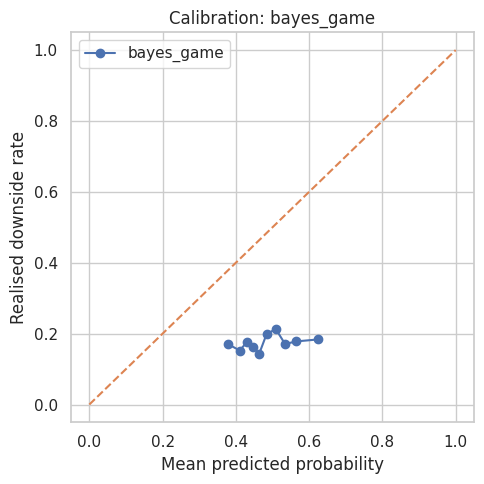

,bin,mean_pred,realised,n
0,"(0.357, 0.422]",0.408859,0.166972,545
1,"(0.422, 0.435]",0.429201,0.185321,545
2,"(0.435, 0.446]",0.440666,0.139450,545
3,"(0.446, 0.456]",0.450976,0.174632,544
4,"(0.456, 0.475]",0.464647,0.135780,545
5,"(0.475, 0.5]",0.488281,0.179817,545
6,"(0.5, 0.519]",0.509783,0.204044,544
7,"(0.519, 0.535]",0.527419,0.174312,545
8,"(0.535, 0.555]",0.544018,0.188991,545
9,"(0.555, 0.787]",0.593193,0.200000,545


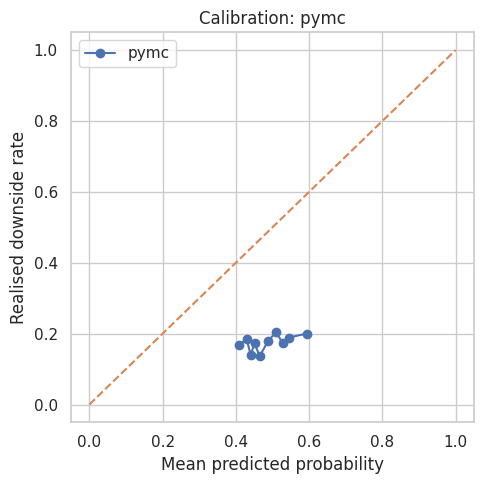

In [ ]:
cal = pd.DataFrame({"y": y_test_r, "bayes_game": bayes_game_p, "pymc": pymc_p})
for c in ["bayes_game", "pymc"]:
    tmp = cal.dropna(subset = [c]).copy()
    tmp["bin"] = pd.qcut(tmp[c], 10, duplicates = "drop")
    table = tmp.groupby("bin").agg(
        mean_pred = (c, "mean"), realised = ("y", "mean"), n = ("y", "size")
    ).reset_index()
    display(table)
    plt.figure(figsize = (5, 5))
    plt.plot(table["mean_pred"], table["realised"], marker = "o", label = c)
    plt.plot([0, 1], [0, 1], linestyle = "--")
    plt.title(f"Calibration: {c}")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Realised downside rate")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Section 7
## Bayesian contextual bandit decision layer

This section converts the downside-risk forecasts into a sequential allocation rule. The previous models estimate the probability of a future downside event,

$$
\hat{p}_{s,t} = P(y_{s,t+5}=1 \mid X_{s,t}),
$$

but a risk forecast is not yet a portfolio decision. The contextual bandit layer uses these forecasts, together with market-regime and institutional-flow variables, to choose between a small set of allocation actions.

At each rebalance date \(t\), the model observes a context vector

$$
c_t =
[
\text{mean downside probability},
\text{max downside probability},
\Delta VIX_t,
RV_{20,t},
DD_t,
FII^z_t,
DII^z_t,
\text{flow imbalance}_t,
P(z_t=k),
\text{absorption}_t,
\text{joint stress}_t
].
$$

The available actions are

$$
a_t \in
\{\text{cash},\text{NIFTY},\text{defensive sectors},\text{cyclical sectors},\text{low-risk sectors}\}.
$$

The bandit treats each action as having an unknown reward function. In simplified form, the expected reward for action \(a\) is modelled as

$$
E[r_{t+1}(a) \mid c_t] = c_t^\top \theta_a,
$$

where \(\theta_a\) is an action-specific parameter vector. The Bayesian component is that the model maintains a posterior belief over each \(\theta_a\), updates it after observing realised returns, and uses Thompson-style sampling to balance exploration and exploitation.

The realised reward is based on the next-period return of the selected allocation:

$$
r_t(a_t) = R_t(a_t) - \text{transaction cost}_t.
$$

The model is first warmed up on the training period, then evaluated on the chronological test period. This preserves the sequential structure: the bandit only updates after observing realised outcomes, rather than using future information in advance.

The benchmark table compares the bandit against fixed allocation rules:

- `cash`: zero-risk allocation proxy;
- `nifty`: passive market exposure;
- `defensive`: average return of defensive sectors;
- `cyclical`: average return of cyclical sectors;
- `low_risk`: sectors with the lowest predicted downside probability;
- `OracleDiagnostic`: an infeasible hindsight benchmark that selects the best action after the fact.

The oracle is included only as a diagnostic upper bound. It should not be interpreted as a real trading strategy, because it uses future realised returns.

The performance metrics test whether the Bayesian decision layer converts forecast information into useful allocation decisions:

$$
\text{Sharpe}
=
\frac{E[R_p]}{\sigma(R_p)},
$$

$$
\text{Max Drawdown}
=
\min_t
\left(
\frac{W_t}{\max_{\tau \leq t} W_\tau} - 1
\right),
$$

where \(W_t\) is cumulative portfolio wealth. The cumulative wealth plot shows realised portfolio growth over time, while the cumulative regret plot measures how much return the bandit gives up relative to the hindsight oracle:

$$
\text{Regret}_T
=
\sum_{t=1}^{T}
\left[
r_t(a_t^\star) - r_t(a_t)
\right],
$$

where \(a_t^\star\) is the best action in hindsight at time \(t\).

This layer is deliberately treated as a decision experiment rather than the main empirical claim. The core project tests whether Bayesian game-regime models improve downside-risk forecasting; the bandit layer asks the additional question of whether those probabilistic forecasts can be translated into a simple allocation rule. If the bandit underperforms passive NIFTY or the low-risk basket, the correct interpretation is not that the forecast model is useless, but that the current decision rule is too simple or too costly to extract the available signal reliably.

In [ ]:
train_r = train_r.copy()
test_r = test_r.copy()
train_r["p_model"] = pymc_train_p if len(pymc_train_p) == len(train_r) else bayes_game_train_p
test_r["p_model"] = np.where(np.isnan(pymc_p), bayes_game_p, pymc_p)

train_rewards = make_bandit_frame(train_r, daily_game, "p_model", cfg)
test_rewards = make_bandit_frame(test_r, daily_game, "p_model", cfg)
context_cols = ["mean_downside_prob", "max_downside_prob", "vix_chg", "rv_20", "drawdown",
                "fii_z", "dii_z", "flow_imbalance", "regime_risk_on", "regime_contested",
                "regime_stress", "p_domestic_absorption", "p_joint_stress"]
context_cols = [c for c in context_cols if c in train_rewards.columns]
bandit_result = run_bandit(train_rewards, test_rewards, context_cols, cfg)

actions = ["cash", "nifty", "defensive", "cyclical", "low_risk"]
bench = pd.DataFrame({"Bandit": bandit_result["reward"], "OracleDiagnostic": bandit_result["oracle_reward"]})
for a in actions:
    bench[a] = test_rewards.iloc[:: cfg.rebalance_step].reset_index(drop = True)[a]
strategy_table = pd.DataFrame({
    c: ModelMetrics.strategy(bench[c], periods = 252 // cfg.rebalance_step)
    for c in bench.columns
}).T
display(strategy_table)
display(bandit_result["action"].value_counts().to_frame("n"))

,Ann_Return,Ann_Vol,Sharpe,Sortino,MaxDD,CVaR_5pct,HitRate
Bandit,0.173373,1.378876e-01,1.257348e+00,1.859169,-0.157495,-0.041244,0.481752
OracleDiagnostic,1.155589,1.152431e-01,1.002740e+01,NaN,0.000000,0.000258,1.000000
cash,0.012979,1.154190e-18,1.124482e+16,NaN,0.000000,0.000258,1.000000
nifty,0.073697,1.263310e-01,5.833670e-01,0.971754,-0.147051,-0.034982,0.518248
defensive,0.057655,1.175861e-01,4.903248e-01,0.763359,-0.225069,-0.034602,0.503650
cyclical,0.168047,1.761586e-01,9.539543e-01,1.560815,-0.172244,-0.049844,0.591241
low_risk,0.228326,1.476806e-01,1.546082e+00,2.648328,-0.127601,-0.037160,0.576642


,n
action,
low_risk,35
cyclical,29
defensive,29
nifty,25
cash,19


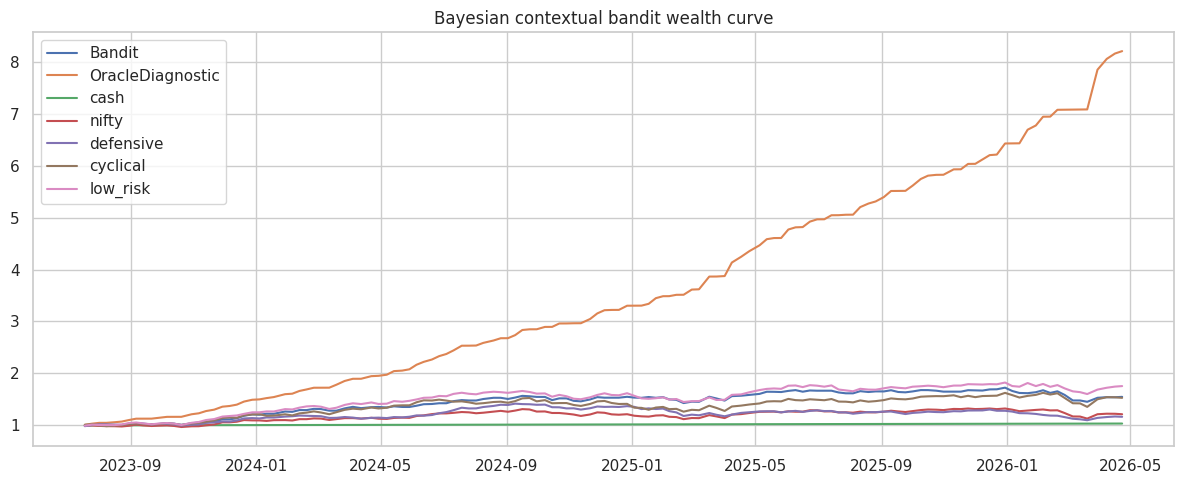

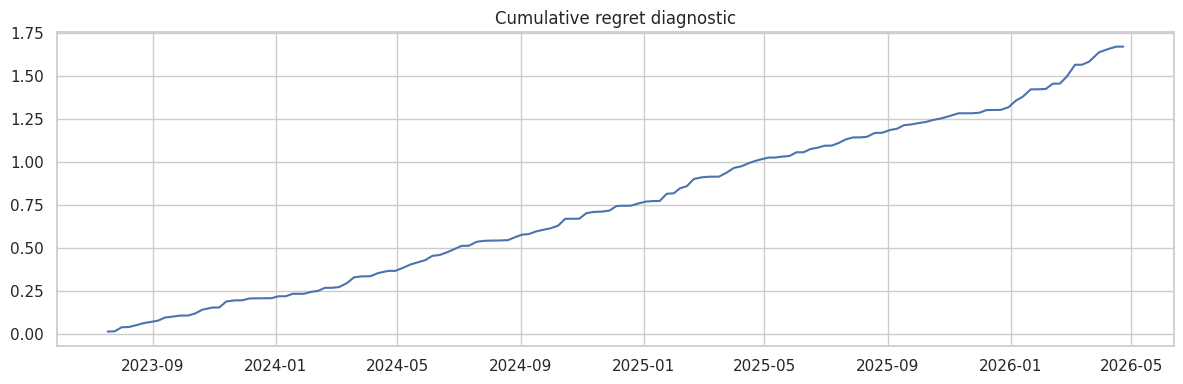

In [ ]:
wealth = (1 + bench).cumprod()
plt.figure(figsize = (12, 5))
for c in wealth.columns:
    plt.plot(bandit_result["date"], wealth[c], label = c)
plt.title("Bayesian contextual bandit wealth curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize = (12, 4))
plt.plot(bandit_result["date"], bandit_result["regret"].cumsum())
plt.title("Cumulative regret diagnostic")
plt.tight_layout()
plt.show()

## Section 8
## Final model dashboard

This final dashboard collects the key results from the notebook into one compact summary. The aim is to compare the main modelling layers on the metrics that are most relevant to their purpose: return prediction, downside-risk probability forecasting and allocation performance.

The return-regression models are summarised using RMSE:

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(r_i - \hat{r}_i)^2
}.
$$

This compares OLS with Bayesian Ridge. A lower RMSE indicates better point prediction of five-day forward sector returns. In this project, the return-regression models are used mainly as benchmarks, since exact return forecasting is usually noisy in financial data.

The downside-risk classifiers are compared using log loss:

$$
\text{LogLoss}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right].
$$

This is the most important forecasting metric in the project because the models output probabilities of future downside events, not just binary predictions. Lower log loss means the model assigns more reliable probability mass to the realised outcomes.

The dashboard compares four probability models:

1. plain logistic regression;
2. Bayesian logistic regression with Laplace approximation;
3. Bayesian game-regime logistic regression;
4. PyMC hierarchical game-regime shrinkage model.

The PyMC model is the most complete Bayesian specification because it combines sector-level partial pooling, institutional game variables, hidden-regime probabilities and posterior uncertainty. If its log loss is lower than the simpler Bayesian models, this supports the claim that the hierarchical game-regime structure adds predictive value.

The strategy section reports Sharpe ratio and maximum drawdown for the Bayesian contextual bandit and passive NIFTY benchmark:

$$
\text{Sharpe}
=
\frac{E[R_p]}{\sigma(R_p)},
$$

and

$$
\text{MaxDD}
=
\min_t
\left(
\frac{W_t}{\max_{\tau \leq t} W_\tau} - 1
\right).
$$

The Sharpe ratio measures risk-adjusted return, while maximum drawdown measures the worst peak-to-trough loss in cumulative wealth. These metrics test whether the probabilistic risk forecasts can be translated into a useful allocation rule.

The dashboard should be read as a layered empirical conclusion. The return models test whether future sector returns are linearly predictable. The classification models test whether downside risk can be forecast probabilistically. The PyMC model tests whether Bayesian hierarchy, regimes and institutional interaction improve the risk model. The bandit results test whether those forecasts can support a simple sequential allocation policy.

The strongest interpretation is therefore not based on a single number. A high-quality result is one where the advanced Bayesian model improves probabilistic downside-risk forecasting, while the strategy results are assessed separately as an applied decision experiment.

In [ ]:
dashboard = pd.DataFrame({
    "OLS_RMSE": [ols_metrics["RMSE"]],
    "Bayesian_Ridge_RMSE": [bayes_ridge_metrics["RMSE"]],
    "Logistic_LogLoss": [logit_metrics["LogLoss"]],
    "Bayesian_LogLoss": [bayes_metrics["LogLoss"]],
    "Game_Regime_LogLoss": [bayes_game_metrics["LogLoss"]],
    "PyMC_LogLoss": [pymc_metrics["LogLoss"]],
    "Bandit_Sharpe": [strategy_table.loc["Bandit", "Sharpe"]],
    "Nifty_Sharpe": [strategy_table.loc["nifty", "Sharpe"] if "nifty" in strategy_table.index else np.nan],
    "Bandit_MaxDD": [strategy_table.loc["Bandit", "MaxDD"]],
}).T.rename(columns = {0: "value"})
display(dashboard)

,value
OLS_RMSE,0.029001
Bayesian_Ridge_RMSE,0.028943
Logistic_LogLoss,0.467614
Bayesian_LogLoss,0.684713
Game_Regime_LogLoss,0.682573
PyMC_LogLoss,0.678795
Bandit_Sharpe,1.257348
Nifty_Sharpe,0.583367
Bandit_MaxDD,-0.157495
